# Full 3D Pose Estimation Pipeline
This notebook combines 2D pose detection and 3D reconstruction steps.

In [1]:
import os
import numpy as np
from tqdm import tqdm
from ultralytics import YOLO
import pickle
from scipy.optimize import least_squares, minimize
import torch

from helpers.predictors import *
from helpers.json_handling import read_keypoints_mmpose
from helpers.camera import *
from helpers.definitions import *
from helpers.plotting import *
from helpers.pose_construction import *

from helpers.weakloss import BMCLoss

# Configuration
data_collection = 'cha/cha_short'  # Change this to match your data collection
show = True  # Show visualizations
resolution = (960, 540)  # Processing resolution
original_resolution = (3840, 2160)  # Original video resolution
max_hands = 2  # Maximum number of hands to track per person

FORCE_RETRAIN = False  # Force rerunning of optimization

# Camera configuration
far_field_cameras = []  # Specify which cameras to use
near_field_cameras = []  # Specify which cameras to use
for i in range(1, 13):
    if i < 5:
        far_field_cameras.append('gopro' + str(i))
    else:
        near_field_cameras.append('gopro' + str(i))


Device: cuda
Torch compile enabled: True


## Initialize Models
Initialize all required models for detection and pose estimation.

In [2]:
# Initialize YOLO models for hand detection
model_person = YOLO('checkpoints/yolo/yolo11l.pt')
model_hand = YOLO('checkpoints/yolo/rohan_pretrained.pt')

# Configure model settings
model_hand.conf = 0.3  # NMS confidence threshold
model_hand.iou = 0.3   # NMS IoU threshold

# Initialize models with TAM tracker
USE_TAM = True
initialize_models(use_tam=USE_TAM, use_wholebody=True)

# Set up paths
data_dir = f'inputs/{data_collection}'  # Input video directory
pose_output_dir = f'pose_outputs/{data_collection}'  # 2D pose output directory
output_3d_dir = f'output_3d/{data_collection}'  # 3D pose output directory
detection_dir = f'outputs/{data_collection}'  # Directory containing detection txt files

os.makedirs(pose_output_dir, exist_ok=True)
os.makedirs(output_3d_dir, exist_ok=True)

Loads checkpoint by local backend from path: checkpoints/hands/detection/cascade_rcnn_x101_64x4d_fpn_20e_onehand10k-dac19597_20201030.pth
Loads checkpoint by local backend from path: checkpoints/body/detection/rtmdet_m_8xb32-100e_coco-obj365-person-235e8209.pth
Disable torch compile due to unsupported GPU.
Loads checkpoint by local backend from path: checkpoints/hands/pose/rtmpose-m_simcc-hand5_pt-aic-coco_210e-256x256-74fb594_20230320.pth
Loads checkpoint by local backend from path: checkpoints/body/pose/rtmpose-x_simcc-body7_pt-body7-halpe26_700e-384x288-7fb6e239_20230606.pth
Loads checkpoint by local backend from path: checkpoints/wholebody/rtmpose-l_simcc-coco-wholebody_pt-aic-coco_270e-384x288-eaeb96c8_20230125.pth


c:\Users\aelvy\miniconda3\envs\orpose\Lib\site-packages\mmengine\utils\manager.py:113: UserWarning: <class 'mmpose.visualization.local_visualizer.PoseLocalVisualizer'> instance named of visualizer has been created, the method `get_instance` should not accept any other arguments
  warnings.warn(


Models initialized with EfficientTAM tracker
Pose estimation models initialized
YOLO models initialized


## Process Videos and Extract 2D Poses

In [3]:
def process_single_video(video_name):
    """Process a single video to extract 2D poses"""
    video_path = os.path.join(data_dir, f"{video_name}.MP4")
    if not os.path.exists(video_path):
        print(f"Video not found: {video_path}")
        return False

    print(f"Processing {video_name}...")

    # Process frames and estimate poses
    pred_instances_body = []
    cap = cv2.VideoCapture(video_path)

    if os.path.exists(os.path.join(pose_output_dir, f"{video_name}_body.json")):
        print(f"Skipping {video_name} - already processed")
        return int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    # Detect body poses
    bboxes_body = detect_body(video_path)

    frame_idx = 0
    while cap.isOpened():
        success, frame = cap.read()
        if not success:
            break
            
        # Estimate body pose
        bbox = np.array(bboxes_body[frame_idx])
        if len(bbox.shape) == 1:
            bbox = bbox.reshape((1, 4))
            
        pred_instances = estimate_pose(frame, bbox, pose_type='body', show=False)
        
        # Convert instances to JSON-serializable format
        instances_json = []
        if pred_instances is not None:
            for instance in split_instances(pred_instances):
                instance_json = {
                    'keypoints': np.array(instance['keypoints']).astype(float).tolist(),
                    'keypoint_scores': np.array(instance['keypoint_scores']).astype(float).tolist()
                }
                if 'bbox' in instance:
                    instance_json['bbox'] = np.array(instance['bbox']).astype(float).tolist()
                    if 'bbox_score' in instance:
                        instance_json['bbox_score'] = float(instance['bbox_score'])
                instances_json.append(instance_json)

        pred_instances_body.append(dict(
            frame_id=frame_idx,
            instances=instances_json
        ))
        
        frame_idx += 1
        print(f"\rProcessing frame {frame_idx}", end='')

    print(". Done!")
        
    cap.release()
    
    # Save predictions
    save_path = os.path.join(pose_output_dir, f"{video_name}_body.json")
    with open(save_path, 'w') as f:
        json.dump({
            'instance_info': pred_instances_body
        }, f, indent=2)
        
    return frame_idx

# Process all videos
for video_file in os.listdir(data_dir):
    if video_file.endswith('.MP4'):
        video_name = os.path.splitext(video_file)[0]
        # Check if video is from an allowed camera
        if any(video_name.startswith(cam + '_') for cam in far_field_cameras):
            total_frames = process_single_video(video_name)
        else:
            print(f"Skipping {video_name} - not in far field cameras list")

Skipping gopro10_synced_cut - not in far field cameras list
Skipping gopro11_synced_cut - not in far field cameras list
Skipping gopro12_synced_cut - not in far field cameras list
Skipping gopro13_synced_cut - not in far field cameras list
Processing gopro1_synced_cut...
Skipping gopro1_synced_cut - already processed
Processing gopro2_synced_cut...
Skipping gopro2_synced_cut - already processed
Processing gopro3_synced_cut...
Skipping gopro3_synced_cut - already processed
Processing gopro4_synced_cut...
Skipping gopro4_synced_cut - already processed
Skipping gopro5_synced_cut - not in far field cameras list
Skipping gopro6_synced_cut - not in far field cameras list
Skipping gopro7_synced_cut - not in far field cameras list
Skipping gopro8_synced_cut - not in far field cameras list
Skipping gopro9_synced_cut - not in far field cameras list


## Reconstruct 3D Poses
Load 2D poses and camera parameters, then reconstruct 3D poses.

Hand keypoints not available for cam: gopro1
Hand keypoints not available for cam: gopro2
Hand keypoints not available for cam: gopro3
Hand keypoints not available for cam: gopro4
Body keypoints not available for cam: gopro5
Hand keypoints not available for cam: gopro5
Body keypoints not available for cam: gopro6
Hand keypoints not available for cam: gopro6
Body keypoints not available for cam: gopro7
Hand keypoints not available for cam: gopro7
Body keypoints not available for cam: gopro8
Hand keypoints not available for cam: gopro8
Body keypoints not available for cam: gopro9
Hand keypoints not available for cam: gopro9
Body keypoints not available for cam: gopro10
Hand keypoints not available for cam: gopro10
Body keypoints not available for cam: gopro11
Hand keypoints not available for cam: gopro11
Body keypoints not available for cam: gopro12
Hand keypoints not available for cam: gopro12


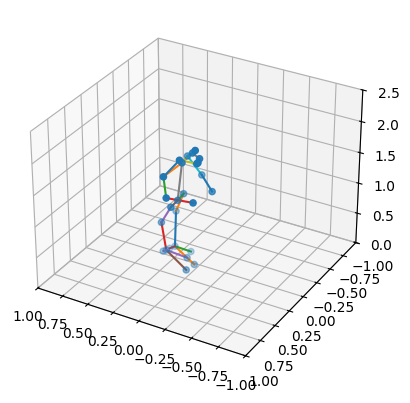

In [4]:
# Load camera parameters
camera_params_dir = f'camera_poses/{data_collection.split("/")[0]}'


camera_intrinsics, camera_extrinsics, distortion_coeffs, camera_matrices = load_camera_params(
    os.path.join(camera_params_dir, 'camera_intrinsics'),
    os.path.join(camera_params_dir, 'camera_extrinsics/aligned_poses.json'),
    suffix='_synced',
    named=True,
    import_extrinsics_matrix=True
)

far_field_cam_intr = [camera_intrinsics[cam] for cam in far_field_cameras]
far_field_cam_extr = [camera_extrinsics[cam] for cam in far_field_cameras]
far_field_cam_dist = [distortion_coeffs[cam] for cam in far_field_cameras]
far_field_cam_mat = [camera_matrices[cam] for cam in far_field_cameras]

# Read 2D keypoints from JSON files
poses_2d_body, _ = read_keypoints_mmpose(
    pose_output_dir, 
    cam_names, 
    num_frames=total_frames,  # Use dynamically determined frame count
    suffix='_synced_cut'
)

# Mask keypoints based on confidence
poses_2d_masked = mask_keypoints(
    poses_2d_body, 
    confidence_threshold=0.3, 
    min_cameras=2, 
    num_keypoints=26
)

# Reconstruct 3D poses
poses_3d_body = reconstruct_3d_pose(
    poses_2d_masked,
    far_field_cam_intr,
    far_field_cam_extr,
    far_field_cam_dist,
    far_field_cam_mat,
    regularization_weight=1.0,
    reprojection_weight=1.0,
    smoothing=True
)

# Save results
output_file = os.path.join(output_3d_dir, 'poses_3d.npz')
np.savez(
    output_file,
    poses_2d=poses_2d_body,
    poses_3d=poses_3d_body
)

# Visualize results
if show:
    pose2video(
        poses_3d_body,
        output_3d_dir,
        'visualization',
        xlim=(1, -1),
        ylim=(1, -1),
        zlim=(0, 2.5)
    )

## Hand Detection and Tracking
Using pre-trained YOLO models for person and hand detection, followed by hand pose estimation and tracking. The system first detects persons using YOLOv8, then searches for hands within detected person regions using a specialized hand detection model.

In [5]:

def crop_img(img, box):
    """Crop image based on bounding box"""
    x1, y1, x2, y2 = box
    return img[int(y1):int(y2), int(x1):int(x2)]

def detect_hands_in_frame(frame):
    """Detect hands in a single frame using YOLO model"""
    # Process frame with YOLO
    results = model_person(frame, classes=0)
    # print(results)
    boxes = []
    confidence = []
    
    if len(results) == 0:
        results_hands = model_hand(frame)
        for r in results_hands:
            boxes_tensor = r.boxes.xyxy.cpu()
            confs = r.boxes.conf.cpu()
            for box, conf in zip(boxes_tensor, confs):
                if conf > model_hand.conf:
                    boxes.append(box.flatten())
                    confidence.append(conf)
    # Process detections
    for r in results:
        boxes_tensor = r.boxes.xyxy.cpu()
        confs = r.boxes.conf.cpu()
        for box1, conf in zip(boxes_tensor, confs):
            cropped = crop_img(frame, box1)
            results_hands = model_hand(cropped)
            for r in results_hands:
                boxes_tensor = r.boxes.xyxy.cpu()
                confs = r.boxes.conf.cpu()
                for box2, conf in zip(boxes_tensor, confs):
                    if conf > model_hand.conf:
                        # print(box2)
                        adjusted_box = np.add(np.array(box2).reshape(2, 2), box1[:2])
                        boxes.append(adjusted_box.flatten())
                        confidence.append(conf)
                       
                
    return np.array(boxes) if boxes else np.array([]), np.array(confidence) if confidence else np.array([])

def process_video_rohan(input_file, show=True):
    """Process video file for hand detection"""
    cap = cv2.VideoCapture(input_file)
    if not cap.isOpened():
        raise FileNotFoundError(f"Cannot open video file: {input_file}")
    
    frame_idx = 0
    output_boxes = []
    out_frame_idx = None
    
    success = True
    while cap.isOpened() and success:   
        success, frame = cap.read()
        if not success:
            break
            
        # Detect hands
        boxes, confidence = detect_hands_in_frame(frame)
        
        if len(boxes) > 0:
            output_boxes.append((boxes, confidence, frame_idx))
            
        if show:
            # Visualize detections
            for box, conf in zip(boxes, confidence):
                x1, y1, x2, y2 = map(int, box)
                cv2.rectangle(frame, (x1, y1), (x2, y2), (255, 0, 255), 2)
                cv2.putText(frame, f"Hand, conf: {round(100*conf, 1)}%", (x1 - 30, y1 - 30), cv2.FONT_HERSHEY_PLAIN, 2, (255, 0, 255), 2)
            
            cv2.namedWindow('Detections', cv2.WINDOW_NORMAL)
            cv2.resizeWindow('Detections', 1920, 1080)
            cv2.imshow('Detections', frame)
            if cv2.waitKey(1) == 113:
                success = False

                
        frame_idx += 1
        print(f"Processing frame {frame_idx}", end='\r')
    
    cap.release()
    if show:
        cv2.destroyAllWindows()
        
    return output_boxes

def save_to_file(boxes, output_file):
    
    # Save output to file
    with open(output_file, 'w+') as f:
        for boxes, conf, frame_idx in boxes:
            f.write(f"{frame_idx} ")
            for i, box in enumerate(boxes):
                f.write(f"{box[0]} {box[1]} {box[2]} {box[3]} {conf[i]} ")
            f.write("\n")

In [6]:
# Process all videos in the inputs folder
for video_file in os.listdir(data_dir):
    if video_file.endswith('.MP4'):
        video_name = os.path.splitext(video_file)[0]
        if any(video_name.startswith(cam) for cam in near_field_cameras):
            print(f"\nProcessing video: {video_name}")
            video_path = os.path.join(data_dir, video_file)

            if os.path.exists(f"outputs/{data_collection}/{video_name}.txt"):
                print("Output already exists, skipping")
                continue
            # Process the video
            bboxes = process_video_rohan(video_path, show=show)
            
            if len(bboxes) == 0:
                print("No hands detected")
            else:
                (boxes, conf, frame_idxs) = zip(*bboxes)
                print(f"\nFound hands at frame {frame_idxs}")
                print(f"Bounding boxes: \n{boxes}")

                os.makedirs(f"outputs/{data_collection}", exist_ok=True)
                save_to_file(bboxes, f"outputs/{data_collection}/{video_name}.txt")


Processing video: gopro10_synced_cut
Output already exists, skipping

Processing video: gopro11_synced_cut
Output already exists, skipping

Processing video: gopro12_synced_cut

0: 384x640 (no detections), 64.8ms
Speed: 0.0ms preprocess, 64.8ms inference, 95.3ms postprocess per image at shape (1, 3, 384, 640)
Processing frame 1
0: 384x640 (no detections), 29.2ms
Speed: 0.0ms preprocess, 29.2ms inference, 0.0ms postprocess per image at shape (1, 3, 384, 640)
Processing frame 2
0: 384x640 (no detections), 35.3ms
Speed: 0.0ms preprocess, 35.3ms inference, 0.0ms postprocess per image at shape (1, 3, 384, 640)
Processing frame 3
0: 384x640 (no detections), 31.9ms
Speed: 0.0ms preprocess, 31.9ms inference, 0.0ms postprocess per image at shape (1, 3, 384, 640)
Processing frame 4
0: 384x640 (no detections), 31.6ms
Speed: 0.0ms preprocess, 31.6ms inference, 0.0ms postprocess per image at shape (1, 3, 384, 640)
Processing frame 5
0: 384x640 (no detections), 31.6ms
Speed: 0.0ms preprocess, 31.6m

## Hand Tracking with EfficientTAM
This section handles hand tracking using the EfficientTAM algorithm. The process first detects people and hands using YOLO models, then uses EfficientTAM to track detected hands through video sequences. This enables robust hand tracking even with rapid movements and partial occlusions.

In [7]:
def read_detection_file(filepath, with_confidence=False):
    """Read detection file containing frame index and bounding boxes"""
    detections = {}
    stride = 5 if with_confidence else 4
    with open(filepath, 'r') as f:
        for line in f:
            values = list(map(float, line.strip().split()))
            frame_idx = int(values[0])
            boxes = []
            # Each box has 4 coordinates
            for i in range(1, len(values), stride):
                boxes.append(values[i:i+4])

            boxes = np.array(boxes)

            if resolution != original_resolution:
                # Rescale bounding boxes to original resolution
                
                boxes[:, 0] *= resolution[0] / original_resolution[0]
                boxes[:, 1] *= resolution[1] / original_resolution[1]
                boxes[:, 2] *= resolution[0] / original_resolution[0]
                boxes[:, 3] *= resolution[1] / original_resolution[1]
            detections[frame_idx] = boxes
    return detections

def prepare_video_frames(video_path, resample_to=None):
    """Create frames directory if video file exists"""
    if not os.path.exists(video_path):
        raise FileNotFoundError(f"Video not found: {video_path}")
        
    video_name = os.path.splitext(os.path.basename(video_path))[0]
    frames_dir = os.path.join(os.path.dirname(video_path), video_name)
    
    if not os.path.exists(frames_dir):
        os.makedirs(frames_dir)
        cap = cv2.VideoCapture(video_path)
        frame_idx = 0
        
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            if resample_to is not None:
                frame = cv2.resize(frame, resample_to)
            cv2.imwrite(os.path.join(frames_dir, f"{frame_idx:05d}.jpg"), frame)
            frame_idx += 1
            
        cap.release()
        
    return frames_dir

In [8]:

def process_video_hands(video_name):
    """Process a single video file and track all boxes as one object"""

    def box_tracked(tracks, frame_idx, box):
        """Check if box is already tracked in the tracks"""

        box_mean_x = (box[0] + box[2]) / 2
        box_mean_y = (box[1] + box[3]) / 2
        if frame_idx not in tracks:
            return False

        for tracked_box in tracks[frame_idx].values():
            if len(tracked_box) == 0:
                continue
            tracked_box = tracked_box.flatten()
            tracked_box_mean_x = (tracked_box[0] + tracked_box[2]) / 2
            tracked_box_mean_y = (tracked_box[1] + tracked_box[3]) / 2
            tracked_in_box = (tracked_box_mean_x >= box[0] and tracked_box_mean_x <= box[2] and tracked_box_mean_y >= box[1] and tracked_box_mean_y <= box[3])
            box_in_tracked = (box_mean_x >= tracked_box[0] and box_mean_x <= tracked_box[2] and box_mean_y >= tracked_box[1] and box_mean_y <= tracked_box[3])
            if tracked_in_box and box_in_tracked:
                return True
        return False

    def is_hand(frame_idx, box, frames_dir):
        """Check if box really detected a hand"""
        # Load the frame
        frame = cv2.imread(os.path.join(frames_dir, f"{frame_idx:05d}.jpg"))
        box = box.astype(int)
        print(box)

        # Predict hand pose
        pose = estimate_pose(frame, box, pose_type='hand', show=False, write_img=None)
        print(np.mean(pose.keypoint_scores), IS_HAND_THRESHOLD)
        print(np.max(pose.keypoint_scores), IS_HAND_THRESHOLD)
        print(np.mean(pose.keypoint_scores) >= IS_HAND_THRESHOLD, np.max(pose.keypoint_scores) >= IS_HAND_THRESHOLD)
        if np.mean(pose.keypoint_scores) >= IS_HAND_THRESHOLD:
            return True
        return False


    # Get paths
    video_path = os.path.join(data_dir, f"{video_name}.MP4")
    detection_path = os.path.join(detection_dir, f"{video_name}.txt")

    if not os.path.exists(detection_path):
        print(f"No detection file found for {video_name}")
        return None, None

    # Prepare video frames
    frames_dir = prepare_video_frames(video_path, resolution)

    # Read detections
    detections = read_detection_file(detection_path, with_confidence=True)

    # Initialize tracker for all boxes under single ID
    obj_id = 0
    all_tracks = None
    predictor = None
    inference_state = None
    frame_names = None

    # Process each frame with detections
    for frame_idx, boxes in detections.items():
        for box in boxes:
            if (all_tracks is None or not box_tracked(all_tracks, frame_idx, box)) and obj_id < max_hands:
                print(f"Frame {frame_idx}: {box}")
                print(f"Object ID: {obj_id}")
                # Initialize tracker with first frame's boxes if not done yet
                inference_state, predictor, frame_names = add_object(
                    frames_dir,
                    input_box=box,
                    frame_idx=frame_idx,
                    obj_id=obj_id,
                    show=show,
                    inference_state=inference_state,
                    predictor_in=predictor)

                # Track the object through video
                _, track_boxes = track_object(
                    frames_dir,
                    inference_state,
                    predictor,
                    frame_names,
                    show=show,
                    prev_bboxes=None,
                    whole_mask=True)

                obj_id += 1
                all_tracks = track_boxes

    if frame_names is None:
        return None, None

    return all_tracks, frame_names

def adjust_tracks(tracks, adj_resolution=resolution, orig_resolution=original_resolution):
    for frame_idx, frame_tracks in tracks.items():
        for obj_id, box in frame_tracks.items():
            box = box.flatten()
            if len(box) == 0:
                continue
            box[0] *= orig_resolution[0] / adj_resolution[0]
            box[1] *= orig_resolution[1] / adj_resolution[1]
            box[2] *= orig_resolution[0] / adj_resolution[0]
            box[3] *= orig_resolution[1] / adj_resolution[1]
            tracks[frame_idx][obj_id] = box
    return tracks

In [9]:
def draw_pose(frame, pred_instance, pose_type='body'):
    """Draw pose keypoints and connections on frame"""
    height, width = frame.shape[:2]
    
    if pose_type == 'hand':
        # Hand keypoint colors
        colors = [(255, 0, 0),   # thumb - red
                 (0, 255, 0),    # index - green
                 (0, 0, 255),    # middle - blue
                 (255, 255, 0),  # ring - yellow
                 (255, 0, 255)]  # pinky - magenta
        
        # Hand connections (finger joints)
        connections = [
            # Thumb
            (0, 1), (1, 2), (2, 3), (3, 4),
            # Index
            (0, 5), (5, 6), (6, 7), (7, 8),
            # Middle
            (0, 9), (9, 10), (10, 11), (11, 12),
            # Ring
            (0, 13), (13, 14), (14, 15), (15, 16),
            # Pinky
            (0, 17), (17, 18), (18, 19), (19, 20)
        ]

        # Draw keypoints and connections
        keypoints = pred_instance.keypoints.squeeze()
        scores = pred_instance.keypoint_scores.squeeze()
        
        # Draw connections first
        for idx, conn in enumerate(connections):
            if scores[conn[0]] > IS_HAND_THRESHOLD and scores[conn[1]] > IS_HAND_THRESHOLD:
                pt1 = tuple(map(int, keypoints[conn[0]]))
                pt2 = tuple(map(int, keypoints[conn[1]]))
                finger_idx = idx // 4  # Determine which finger
                
                # Check if points are within image bounds
                if (0 <= pt1[0] < width and 0 <= pt1[1] < height and 
                    0 <= pt2[0] < width and 0 <= pt2[1] < height):
                    try:
                        cv2.line(frame, pt1, pt2, colors[finger_idx], POSE_VIS_LINE_WIDTH)
                    except:
                        print(f"Error drawing line for connection {conn}: {pt1} to {pt2}")
                        continue

        # Draw keypoints
        for i, (point, score) in enumerate(zip(keypoints, scores)):
            if score > IS_HAND_THRESHOLD:  # Only draw high-confidence keypoints
                x, y = map(int, point)
                # Check if point is within image bounds
                if 0 <= x < width and 0 <= y < height:
                    finger_idx = (i - 1) // 4 if i > 0 else 0  # Determine which finger the point belongs to
                    cv2.circle(frame, (x, y), POSE_VIS_RADIUS, colors[finger_idx], -1)

    elif pose_type == 'body':
        # Body keypoint colors - using consistent colors for different body parts
        colors = {
            'torso': (255, 0, 0),      # red
            'head': (0, 255, 0),       # green
            'arms': (0, 0, 255),       # blue
            'legs': (255, 255, 0)      # yellow
        }

        # Body connections based on MMPose skeleton
        connections = [
            # Torso
            ([5, 6], colors['torso']),      # shoulders
            ([5, 11], colors['torso']),     # left shoulder to hip
            ([6, 12], colors['torso']),     # right shoulder to hip
            ([11, 12], colors['torso']),    # hips
            
            # Head
            ([5, 3], colors['head']),       # left shoulder to neck
            ([6, 3], colors['head']),       # right shoulder to neck
            ([3, 1], colors['head']),       # neck to head
            
            # Arms
            ([5, 7], colors['arms']),       # left arm
            ([7, 9], colors['arms']),       # left forearm
            ([6, 8], colors['arms']),       # right arm
            ([8, 10], colors['arms']),      # right forearm
            
            # Legs
            ([11, 13], colors['legs']),     # left thigh
            ([13, 15], colors['legs']),     # left calf
            ([12, 14], colors['legs']),     # right thigh
            ([14, 16], colors['legs']),     # right calf
        ]

        # Draw keypoints and connections
        keypoints = pred_instance.keypoints.squeeze()
        scores = pred_instance.keypoint_scores.squeeze()

        # Draw connections first
        for (conn, color) in connections:
            if scores[conn[0]] > POSE_KPT_THRESHOLD and scores[conn[1]] > POSE_KPT_THRESHOLD:
                pt1 = tuple(map(int, keypoints[conn[0]]))
                pt2 = tuple(map(int, keypoints[conn[1]]))
                
                # Check if points are within image bounds
                if (0 <= pt1[0] < width and 0 <= pt1[1] < height and 
                    0 <= pt2[0] < width and 0 <= pt2[1] < height):
                    cv2.line(frame, pt1, pt2, color, POSE_VIS_LINE_WIDTH)

        # Draw keypoints
        for i, (point, score) in enumerate(zip(keypoints, scores)):
            if score > POSE_KPT_THRESHOLD:  # Only draw high-confidence keypoints
                x, y = map(int, point)
                # Check if point is within image bounds
                if 0 <= x < width and 0 <= y < height:
                    cv2.circle(frame, (x, y), POSE_VIS_RADIUS, (255, 255, 255), -1)

In [10]:
def process_and_visualize_poses(video_path, tracks, output_dir):
    """Process and visualize body and hand poses"""
    cap = cv2.VideoCapture(video_path)
    video_name = os.path.splitext(os.path.basename(video_path))[0]
    out_path = os.path.join(output_dir, f"{video_name}_poses.mp4")
    
    # Setup video writer
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(out_path, fourcc, 30.0, (int(cap.get(3)), int(cap.get(4))))

    hand_poses_2d = []
    frame_idx = 0
    while cap.isOpened():
        success, frame = cap.read()
        if not success:
            break

        # Project 3D poses to 2D for this camera and frame
        if frame_idx < len(poses_3d_body):
            pose_3d = poses_3d_body[frame_idx]
            # Get camera parameters for this video
            cam_name = video_name.split('_')[0]  # Extract camera name from video name
            if cam_name in camera_matrices:
                cam_intrinsics = camera_intrinsics[cam_name].reshape(3,3)
                cam_extrinsics = camera_extrinsics[cam_name]
                cam_distortion = distortion_coeffs[cam_name]
                
                points_2d = project_points(pose_3d, cam_intrinsics, cam_extrinsics[0], cam_extrinsics[1], cam_distortion)
                
                # Create a body pose instance with the projected points
                body_pose = type('', (), {})()  # Create empty object
                body_pose.keypoints = np.array(points_2d).reshape(-1, 2)
                body_pose.keypoint_scores = np.ones(len(points_2d))  # Assuming all points are valid
                
            else:
                body_pose = None
        else:
            body_pose = None

        hand_pose_2d = {}
        # Estimate hand poses for tracked hands
        if frame_idx in tracks:
            for hand_id, box in tracks[frame_idx].items():
                hand_pose = estimate_pose(frame, box, pose_type='hand', show=False)
                # Draw hand keypoints
                if hand_pose is not None:
                    draw_pose(frame, hand_pose, pose_type='hand')
                    hand_pose_2d[hand_id] = hand_pose
            
        hand_poses_2d.append(hand_pose_2d)
                    
        # Draw body keypoints
        if body_pose is not None:
            draw_pose(frame, body_pose, pose_type='body')

        out.write(frame)
        frame_idx += 1

    cap.release()
    out.release()

    return hand_poses_2d

In [11]:
# Process near field cameras for hand poses
hand_poses_2d = {}
output_file = os.path.join(output_3d_dir, 'hand_poses_2d.npz')
if os.path.exists(output_file):
    print("Hand poses already found, skipping")
    hand_poses_2d = np.load(output_file, allow_pickle=True)['poses_2d'].item()
    
else:
    for video_file in os.listdir(data_dir):
        if video_file.endswith('.MP4'):
            video_name = os.path.splitext(video_file)[0]
            if any(video_name.startswith(cam) for cam in near_field_cameras):
                cam_name = video_name.split('_')[0]
                print(f"\nProcessing {video_name} for hand detection and tracking...")
                video_path = os.path.join(data_dir, video_file)
                
                if os.path.exists(os.path.join(detection_dir, f"tracked_bboxes_{video_name}.pkl")):
                    print(f"Tracks already found for {video_name}")

                    with open(os.path.join(detection_dir, f"tracked_bboxes_{video_name}.pkl"), 'rb') as f:
                        tracks = pickle.load(f)

                else:
                    # Track hands
                    tracks, frame_names = process_video_hands(video_name)

                    if tracks is not None:
                        # Save tracked boxes
                        with open(os.path.join(detection_dir, f"tracked_bboxes_{video_name}.pkl"), 'wb') as f:
                            tracks = adjust_tracks(tracks)
                            pickle.dump(tracks, f)
                
                if tracks is not None: 
                    # Process and visualize poses
                    hand_poses_2d[cam_name] = process_and_visualize_poses(video_path, tracks, pose_output_dir)

    # Save hand poses to file
    np.savez(
        output_file,
        poses_2d=hand_poses_2d,
    )

Hand poses already found, skipping


In [12]:
def match_hand_poses(oriented_hands, pose_2d_dict, camera_intrinsics, rotation, translation, distortion, threshold=200, just_wrist=True, visualize=False, frame=None, hand_id_mapping=None):
    """
    Match 3D hand pose with corresponding 2D hand detection based on reprojection error.
    If hand_id_mapping is provided, use predetermined mapping instead of matching by reprojection.
    
    Args:
        oriented_hand: numpy array (2*num_keypoints_hands, 3) representing 3D hand poses
        pose_2d_dict: dictionary mapping object IDs to 2D hand poses
        camera_intrinsics: camera intrinsic matrix
        rotation: camera rotation matrix
        translation: camera translation vector
        distortion: distortion coefficients
        threshold: maximum allowed reprojection error for matching
        just_wrist: whether to match only the wrist keypoint or all keypoints
        visualize: whether to visualize the matching results
        frame: original image frame for visualization (required if visualize=True)
        hand_id_mapping: dictionary mapping object IDs to hand side (0=left, 1=right)
    
    Returns:
        best_match: best matching 2D pose or None if no good match found
        min_error: minimum reprojection error for best match
        visualization: visualization frame (only if visualize=True)
    """
    if not pose_2d_dict:
        if visualize:
            return (None, float('inf')), (None, float('inf')), frame
        return (None, float('inf')), (None, float('inf'))

    oriented_hand1 = oriented_hands[:num_keypoints_hands]
    oriented_hand2 = oriented_hands[num_keypoints_hands:]

    # If we already have mappings for object IDs, use them directly
    if hand_id_mapping is not None:
        best_match1 = None
        min_error1 = float('inf')
        best_match2 = None
        min_error2 = float('inf')
        
        for obj_id in pose_2d_dict.keys():
            if obj_id in hand_id_mapping:
                # If this object is mapped to left hand (0)
                if hand_id_mapping[obj_id] == 0:
                    best_match1 = obj_id
                    min_error1 = 0  # We're not calculating error here since mapping is predetermined
                # If this object is mapped to right hand (1)
                elif hand_id_mapping[obj_id] == 1:
                    best_match2 = obj_id
                    min_error2 = 0  # We're not calculating error here since mapping is predetermined
        
        # Create visualization if requested
        if visualize:
            vis_frame = frame.copy() if frame is not None else None
            if vis_frame is not None:
                # Draw projected points for initial hand poses
                if not just_wrist:
                    # Left hand (blue)
                    projected_points1 = project_points(oriented_hand1, camera_intrinsics, 
                                        rotation, translation, distortion)
                    for pt in projected_points1:
                        cv2.circle(vis_frame, (int(pt[0]), int(pt[1])), 5, (255, 0, 0), -1)
                    # Right hand (green)
                    projected_points2 = project_points(oriented_hand2, camera_intrinsics, 
                                        rotation, translation, distortion)
                    for pt in projected_points2:
                        cv2.circle(vis_frame, (int(pt[0]), int(pt[1])), 5, (0, 255, 0), -1)
                
                # Draw matched hand poses
                if best_match1 is not None and best_match1 in pose_2d_dict:
                    keypoints = pose_2d_dict[best_match1].keypoints.squeeze()
                    scores = pose_2d_dict[best_match1].keypoint_scores.squeeze()
                    # Draw left hand keypoints (red)
                    for i, (pt, score) in enumerate(zip(keypoints, scores)):
                        if score > 0.3:  # Only draw high-confidence keypoints
                            cv2.circle(vis_frame, (int(pt[0]), int(pt[1])), 5, (0, 0, 255), -1)
                            cv2.putText(vis_frame, str(i), (int(pt[0])+5, int(pt[1])+5), 
                                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1)
                
                if best_match2 is not None and best_match2 in pose_2d_dict:
                    keypoints = pose_2d_dict[best_match2].keypoints.squeeze()
                    scores = pose_2d_dict[best_match2].keypoint_scores.squeeze()
                    # Draw right hand keypoints (magenta)
                    for i, (pt, score) in enumerate(zip(keypoints, scores)):
                        if score > 0.3:  # Only draw high-confidence keypoints
                            cv2.circle(vis_frame, (int(pt[0]), int(pt[1])), 5, (255, 255, 0), -1)
                            cv2.putText(vis_frame, str(i), (int(pt[0])+5, int(pt[1])+5), 
                                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 0), 1)
                
                # Add legend
                cv2.putText(vis_frame, "Blue: Left hand (projected)", (10, 30), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)
                cv2.putText(vis_frame, "Green: Right hand (projected)", (10, 60), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
                cv2.putText(vis_frame, "Red: Matched left hand", (10, 90), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
                cv2.putText(vis_frame, "Yellow: Matched right hand", (10, 120), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 0), 2)
                
                return (best_match1, min_error1), (best_match2, min_error2), vis_frame
        
        return (best_match1, min_error1), (best_match2, min_error2)
    
    # Otherwise calculate the best match using reprojection error
    if just_wrist:
        
        # Project 3D points to 2D
        projected_points1 = project_point(oriented_hand1[0], camera_intrinsics, 
                                    rotation, translation, distortion)
        # Project 3D points to 2D
        projected_points2 = project_point(oriented_hand2[0], camera_intrinsics, 
                                    rotation, translation, distortion)

    else:
        # Project 3D points to 2D
        projected_points1 = project_points(oriented_hand1, camera_intrinsics, 
                                    rotation, translation, distortion)
        # Project 3D points to 2D
        projected_points2 = project_points(oriented_hand2, camera_intrinsics, 
                                    rotation, translation, distortion)
        
    best_match1 = None
    min_error1 = float('inf')

    best_match2 = None
    min_error2 = float('inf')
    
    # Create visualization frame if requested
    vis_frame = None
    if visualize:
        if frame is None:
            raise ValueError("Frame must be provided for visualization")
        vis_frame = frame.copy()
        
        # Draw projected points for initial hand poses
        if not just_wrist:
            # Left hand (blue)
            for pt in projected_points1:
                cv2.circle(vis_frame, (int(pt[0]), int(pt[1])), 5, (255, 0, 0), -1)
            # Right hand (green)
            for pt in projected_points2:
                cv2.circle(vis_frame, (int(pt[0]), int(pt[1])), 5, (0, 255, 0), -1)
    
    # Check each detected hand
    for obj_id, pose_2d in pose_2d_dict.items():
        if pose_2d is None or len(pose_2d.keypoints) == 0:
            continue

        keypoint_scores = pose_2d.keypoint_scores.squeeze()
        keypoints = pose_2d.keypoints.squeeze()

        if just_wrist:
            keypoints = keypoints[0]
            keypoint_scores = keypoint_scores[0]

            error1 = np.linalg.norm(
                    projected_points1 - keypoints
                )


            error2 = np.linalg.norm(
                    projected_points2 - keypoints
                )
            
            if error1 < min_error1 and error1 < threshold and error1 <= error2:
                min_error1 = error1
                best_match1 = obj_id

            elif error2 < min_error1 and error2 < threshold and error2 <= error1:
                min_error2 = error2
                best_match2 = obj_id

        else:
            
            # Calculate error for valid keypoints
            valid_mask = keypoint_scores > 0.3
            if np.any(valid_mask) and np.sum(valid_mask) > 5:
                errors1 = np.linalg.norm(
                    projected_points1[valid_mask] - keypoints[valid_mask], 
                    axis=1
                )
                mean_error1 = np.mean(errors1)

                errors2 = np.linalg.norm(
                    projected_points2[valid_mask] - keypoints[valid_mask],
                    axis=1
                )
                mean_error2 = np.mean(errors2)
                
                if mean_error1 < min_error1 and mean_error1 < threshold and mean_error1 <= mean_error2:
                    min_error1 = mean_error1
                    best_match1 = obj_id

                elif mean_error2 < min_error2 and mean_error2 < threshold and mean_error2 <= mean_error1:
                    min_error2 = mean_error2
                    best_match2 = obj_id
                
    # Add visualization of matched hand poses if requested
    if visualize and vis_frame is not None:
        # Draw matched hand poses
        if best_match1 is not None and best_match1 in pose_2d_dict:
            keypoints = pose_2d_dict[best_match1].keypoints.squeeze()
            scores = pose_2d_dict[best_match1].keypoint_scores.squeeze()
            # Draw left hand keypoints (red)
            for i, (pt, score) in enumerate(zip(keypoints, scores)):
                if score > 0.3:  # Only draw high-confidence keypoints
                    cv2.circle(vis_frame, (int(pt[0]), int(pt[1])), 5, (0, 0, 255), -1)
                    cv2.putText(vis_frame, str(i), (int(pt[0])+5, int(pt[1])+5), 
                                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1)
        
        if best_match2 is not None and best_match2 in pose_2d_dict:
            keypoints = pose_2d_dict[best_match2].keypoints.squeeze()
            scores = pose_2d_dict[best_match2].keypoint_scores.squeeze()
            # Draw right hand keypoints (magenta)
            for i, (pt, score) in enumerate(zip(keypoints, scores)):
                if score > 0.3:  # Only draw high-confidence keypoints
                    cv2.circle(vis_frame, (int(pt[0]), int(pt[1])), 5, (255, 255, 0), -1)
                    cv2.putText(vis_frame, str(i), (int(pt[0])+5, int(pt[1])+5), 
                                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 0), 1)
        
        # Add legend
        cv2.putText(vis_frame, "Blue: Left hand (projected)", (10, 30), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)
        cv2.putText(vis_frame, "Green: Right hand (projected)", (10, 60), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
        cv2.putText(vis_frame, "Red: Matched left hand", (10, 90), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
        cv2.putText(vis_frame, "Yellow: Matched right hand", (10, 120), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 0), 2)
        
        return (best_match1, min_error1), (best_match2, min_error2), vis_frame
    
    if visualize:
        return (best_match1, min_error1), (best_match2, min_error2), vis_frame
        
    return (best_match1, min_error1), (best_match2, min_error2)

In [13]:
bmc = BMCLoss(1, 1, 1)

def optimize_hand_pose(initial_pose, filtered_hand_poses_2d, camera_intrinsics, camera_extrinsics, distortion_coeffs, previous_pose=None, lambdas=[1.0, 1e-4, 1.0]):
    """
    Optimize 3D hand pose with BMC constraints using PyTorch operations and autograd.
    """
    # Convert inputs to torch tensors
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Initialize the optimization variable as a PyTorch tensor requiring gradients
    x_tensor = torch.tensor(initial_pose.flatten(), dtype=torch.float32, device=device, requires_grad=True)
    
    if previous_pose is not None:
        prev_pose_tensor = torch.tensor(previous_pose.flatten(), dtype=torch.float32, device=device)
    else:
        prev_pose_tensor = None
        
    # Setup camera parameters as tensors
    camera_params = {}
    for cam_name, hand_pose_2d in filtered_hand_poses_2d.items():
        intr = torch.tensor(camera_intrinsics[cam_name].reshape(3, 3), dtype=torch.float32, device=device)
        rotation = torch.tensor(camera_extrinsics[cam_name][0], dtype=torch.float32, device=device)
        translation = torch.tensor(camera_extrinsics[cam_name][1], dtype=torch.float32, device=device)
        distortion = torch.tensor(distortion_coeffs[cam_name], dtype=torch.float32, device=device)
        
        keypoints = torch.tensor(hand_pose_2d.keypoints.squeeze(), dtype=torch.float32, device=device)
        keypoint_scores = torch.tensor(hand_pose_2d.keypoint_scores.squeeze(), dtype=torch.float32, device=device)
        
        camera_params[cam_name] = {
            'intrinsics': intr,
            'rotation': rotation,
            'translation': translation,
            'distortion': distortion,
            'keypoints': keypoints,
            'keypoint_scores': keypoint_scores
        }
        
    # Define the project_points_torch function for differentiable projection
    def project_points_torch(points_3d, intrinsics, rotation, translation, distortion):
        """Differentiable projection of 3D points to 2D using PyTorch."""
        # Apply rotation and translation
        points_rotated = torch.matmul(points_3d, rotation.transpose(-1, -2)) + translation
        
        # Project to image plane (normalized coordinates)
        x = points_rotated[:, 0] / points_rotated[:, 2]
        y = points_rotated[:, 1] / points_rotated[:, 2]
        
        # Apply radial distortion (simplified, can be expanded)
        r2 = x*x + y*y
        radial = 1.0 + distortion[0]*r2 + distortion[1]*(r2*r2)
        
        xd = x * radial
        yd = y * radial
        
        # Apply tangential distortion (simplified)
        tangential_x = 2 * distortion[2] * x * y + distortion[3] * (r2 + 2 * x * x)
        tangential_y = distortion[2] * (r2 + 2 * y * y) + 2 * distortion[3] * x * y
        
        xd = xd + tangential_x
        yd = yd + tangential_y
        
        # Apply camera matrix
        u = intrinsics[0, 0] * xd + intrinsics[0, 2]
        v = intrinsics[1, 1] * yd + intrinsics[1, 2]
        
        return torch.stack([u, v], dim=-1)
    
    # Define the loss function with PyTorch operations
    def loss_fn(x_param, verbose=False):
        x_reshaped = x_param.reshape(-1, 3)
        
        # Reprojection loss
        repr_loss = 0.0
        total_score = 0.0
        
        for cam_name, params in camera_params.items():
            # Project 3D points to 2D using our PyTorch-based function
            projected_points = project_points_torch(
                x_reshaped, 
                params['intrinsics'], 
                params['rotation'], 
                params['translation'], 
                params['distortion']
            )
            
            # Calculate reprojection error with valid keypoints
            valid_mask = params['keypoint_scores'] > 0.1
            
            if torch.any(valid_mask):
                # Calculate distance between projected and observed keypoints
                error = torch.norm(
                    projected_points[valid_mask] - params['keypoints'][valid_mask],
                    dim=1
                )
                
                # Weight error by keypoint scores
                weighted_error = error * params['keypoint_scores'][valid_mask]
                repr_loss += torch.sum(weighted_error)
                total_score += torch.sum(params['keypoint_scores'][valid_mask])
        
        # Avoid division by zero
        if total_score > 0:
            repr_loss = repr_loss / total_score
        
        # Temporal consistency loss
        temp_loss = 0.0
        if prev_pose_tensor is not None:
            temp_loss = torch.norm(x_param - prev_pose_tensor)
        
        # BMC loss calculation
        x_for_bmc = x_param.reshape(1, -1, 3)
        bmc_loss, _ = bmc.compute_loss(x_for_bmc)
        
        # Combine all losses
        total_loss = lambdas[0] * repr_loss + lambdas[1] * temp_loss + lambdas[2] * bmc_loss

        if verbose:
            if type(repr_loss) == float:
                print(f"Reprojection loss: {repr_loss}")
            else:
                print(f"Reprojection loss: {repr_loss.item()}")
            print(f"Temporal loss: {temp_loss}")
            print(f"BMC loss: {bmc_loss.item()}")
            print(f"Total loss: {total_loss.item()}")
        
        return total_loss
    
    # Initialize LBFGS optimizer
    optimizer = torch.optim.LBFGS(
        [x_tensor], 
        line_search_fn='strong_wolfe',
        max_iter=20,
        tolerance_grad=1e-7,
        tolerance_change=1e-9
    )
    
    # Initial loss calculation
    print("Initial Loss:")
    initial_loss = loss_fn(x_tensor, verbose=True)
    
    # Define closure function for optimizer
    def closure():
        optimizer.zero_grad()
        loss = loss_fn(x_tensor)
        loss.backward()
        return loss
    
    for i in range(10):
        # Run optimization
        optimizer.step(closure)
    
    # Final loss and results
    print(f"Final loss:")
    final_loss = loss_fn(x_tensor, verbose=True)
    
    # Convert result back to numpy
    optimized_hand = x_tensor.detach().cpu().numpy().reshape(-1, 3)
    
    return optimized_hand

In [14]:
def optimize_poses(initial_hand_poses_3d, hand_poses_2d, camera_intrinsics, camera_extrinsics, distortion_coeffs, frame_idx=0, previous_pose=None, visualize=False, input_dir=None, hand_id_mapping=None):
    """
    Optimize 3D hand poses by minimizing reprojection error across multiple views.
    
    Args:
        initial_hand_poses_3d: Initial 3D hand poses
        hand_poses_2d: Dictionary of 2D hand poses
        camera_intrinsics: Camera intrinsic parameters
        camera_extrinsics: Camera extrinsic parameters
        distortion_coeffs: Camera distortion coefficients
        frame_idx: Current frame index
        previous_pose: Previous optimized pose for temporal consistency
        visualize: Whether to visualize the matching process
        input_dir: Directory containing input videos (required if visualize=True)
        hand_id_mapping: Dictionary mapping camera names to a dict of object IDs to hand side (0=left, 1=right)
    """
    optimized_hands = []
    filtered_hand_poses_2d1 = {}  # Left hand
    filtered_hand_poses_2d2 = {}  # Right hand
    
    if previous_pose is not None:
        previous_pose1 = previous_pose[:num_keypoints_hands]  # Left hand
        previous_pose2 = previous_pose[num_keypoints_hands:]  # Right hand
    else:
        previous_pose1 = None
        previous_pose2 = None

    for cam_name, hand_pose_2d in hand_poses_2d.items():
        # Check if we have a predefined mapping for this camera
        cam_mapping = None if hand_id_mapping is None else hand_id_mapping.get(cam_name)
        
        if cam_mapping is not None:
            # Use predefined mapping instead of matching
            for obj_id, hand_side in cam_mapping.items():
                if obj_id in hand_pose_2d[frame_idx]:
                    if hand_side == 0:  # Left hand
                        filtered_hand_poses_2d1[cam_name] = hand_pose_2d[frame_idx][obj_id]
                    elif hand_side == 1:  # Right hand
                        filtered_hand_poses_2d2[cam_name] = hand_pose_2d[frame_idx][obj_id]
        else:
            # No mapping available, perform matching
            if visualize and input_dir is not None:
                # Visualize the hand poses on the original frame
                video_path = os.path.join(input_dir, cam_name + '_synced_cut.MP4')
                cap = cv2.VideoCapture(video_path)
                 
                if not cap.isOpened():
                    print(f"Error opening video file: {video_path}")
                    continue
                cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
                res, frame = cap.read()
                cap.release()
                if frame is None:
                    print(f"Frame not found: {frame_idx}")
                    continue

                (best_match1, min_error1), (best_match2, min_error2), vis_frame = match_hand_poses(
                    initial_hand_poses_3d, hand_pose_2d[frame_idx], camera_intrinsics[cam_name],
                    camera_extrinsics[cam_name][0], camera_extrinsics[cam_name][1],
                    distortion_coeffs[cam_name], just_wrist=False, visualize=visualize, frame=frame
                )
                print(f"Best match for left hand: {best_match1}, error: {min_error1}")
                print(f"Best match for right hand: {best_match2}, error: {min_error2}")
                cv2.namedWindow("Matched Hands", cv2.WINDOW_NORMAL)
                cv2.resizeWindow("Matched Hands", 1920, 1080)  # Resize to a comfortable size
                cv2.imshow("Matched Hands", vis_frame)
                # Wait for user input (press any key to continue, ESC to exit)
                key = cv2.waitKey(0)  # 0 means wait indefinitely until a key is pressed
                if key == 27:  # ESC key to exit
                    cv2.destroyAllWindows()
            else:
                (best_match1, min_error1), (best_match2, min_error2) = match_hand_poses(
                    initial_hand_poses_3d, hand_pose_2d[frame_idx], camera_intrinsics[cam_name],
                    camera_extrinsics[cam_name][0], camera_extrinsics[cam_name][1],
                    distortion_coeffs[cam_name], just_wrist=False
                )
            
            # Store matched poses
            if best_match1 is not None:
                filtered_hand_poses_2d1[cam_name] = hand_pose_2d[frame_idx][best_match1]
            if best_match2 is not None:
                filtered_hand_poses_2d2[cam_name] = hand_pose_2d[frame_idx][best_match2]

    # Optimize hand poses
    optimized_hand1 = optimize_hand_pose(
        initial_hand_poses_3d[:num_keypoints_hands], filtered_hand_poses_2d1,
        camera_intrinsics, camera_extrinsics, distortion_coeffs, 
        previous_pose=previous_pose1
    )
    
    optimized_hand2 = optimize_hand_pose(
        initial_hand_poses_3d[num_keypoints_hands:], filtered_hand_poses_2d2,
        camera_intrinsics, camera_extrinsics, distortion_coeffs, 
        previous_pose=previous_pose2
    )

    # Combine optimized hands
    optimized_hands.append(np.concatenate([optimized_hand1, optimized_hand2], axis=0))
    return np.array(optimized_hands).squeeze()


In [15]:
def orient_canonical_hand(canonical_hand, body_pose_3d, side='right'):
    """
    Orient the canonical hand pose based on arm orientation from body pose.
    
    Args:
        canonical_hand: numpy array of shape (num_keypoints_hands, 3) representing the canonical hand pose
        body_pose_3d: numpy array of shape (num_keypoints, 3) representing the body pose
        side: str, 'right' or 'left' indicating which arm to use
    
    Returns:
        oriented_hand: numpy array of shape (num_keypoints_hands, 3) with oriented hand pose
    """
    # Get indices for arm keypoints based on side
    if side == 'right':
        shoulder_idx, elbow_idx, wrist_idx = 6, 8, 10  # Right arm indices
    else:
        shoulder_idx, elbow_idx, wrist_idx = 5, 7, 9   # Left arm indices
        
    # Extract arm keypoints
    shoulder = body_pose_3d[shoulder_idx]
    elbow = body_pose_3d[elbow_idx]
    wrist = body_pose_3d[wrist_idx]
    
    # Calculate arm vectors
    forearm = wrist - elbow  # Vector from elbow to wrist
    upper_arm = elbow - shoulder  # Vector from shoulder to elbow
    
    # Create orthonormal coordinate system
    y_axis = forearm / np.linalg.norm(forearm)  # Forward direction along forearm

    # Ensure z_axis points inward (towards the body)
    z_axis = np.cross(upper_arm, forearm)
    z_axis = z_axis / np.linalg.norm(z_axis)  # Normalized vector perpendicular to forearm and upper arm

    # If this is a left hand, flip the x-axis to maintain proper handedness
    if side == 'right':
        z_axis = -z_axis

        # x_axis should be perpendicular to y_axis and lie in the arm plane
        x_axis = np.cross(y_axis, z_axis)       

    else:
        # x_axis should be perpendicular to y_axis and lie in the arm plane
        x_axis = - np.cross(y_axis, z_axis)

    x_axis = x_axis / np.linalg.norm(x_axis)
        
    # Create rotation matrix
    rotation_matrix = np.stack([x_axis, y_axis, z_axis], axis=0)
    
    # Rotate canonical hand
    oriented_hand = canonical_hand @ rotation_matrix
    
    # Translate to wrist position
    oriented_hand = oriented_hand + wrist
    
    return oriented_hand

In [16]:
initial_hand_poses_3d = []
for frame_idx in range(len(poses_3d_body)):
    oriented_hand = orient_canonical_hand(CANONICAL_HAND_POSE_3D, poses_3d_body[frame_idx], side='left')
    oriented_hand = np.concatenate([oriented_hand, orient_canonical_hand(CANONICAL_HAND_POSE_3D, poses_3d_body[frame_idx], side='right')])
    initial_hand_poses_3d.append(oriented_hand)

initial_hand_poses_3d = np.array(initial_hand_poses_3d)
initial_hand_poses_3d.shape

(60, 42, 3)

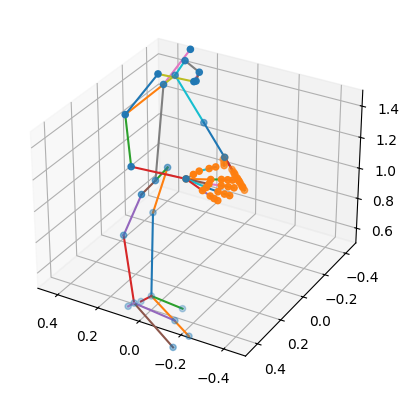

In [17]:
pose2video(
    poses_3d_body,
    output_3d_dir,
    'visualization_initialized_hands',
    initial_hand_poses_3d,
    xlim=(0.5, -0.5),
    ylim=(0.5, -0.5),
    zlim=(0.5, 1.5)
)

In [18]:
def visualize_poses(frame, body_pose_3d, initial_hands_3d, hand_poses_2d, 
                    camera_intrinsics, rotation, translation, distortion, 
                    frame_idx, cam_name, draw_reprojected_only=True, 
                    draw_body=True, draw_hands=True):
    """
    Visualize body poses, 3D hand poses, and 2D hand detections on a frame.
    
    Args:
        frame: Input image/frame
        body_pose_3d: 3D body pose (num_keypoints, 3)
        initial_hands_3d: 3D hand poses (num_hands * num_keypoints_hands, 3)
        hand_poses_2d: Dictionary of 2D hand poses for current frame
        camera_intrinsics: Camera intrinsic matrix (3x3)
        rotation: Camera rotation matrix
        translation: Camera translation vector
        distortion: Distortion coefficients
        frame_idx: Current frame index
        cam_name: Camera name
        draw_reprojected_only: Whether to draw only reprojected poses (not detected ones)
        draw_body: Whether to draw body poses
        draw_hands: Whether to draw hand poses
    """
    # Create copy of frame for drawing
    vis_frame = frame.copy()
    
    # Project and draw 3D body pose
    if body_pose_3d is not None and draw_body:
        body_2d = project_points(body_pose_3d, camera_intrinsics, 
                               rotation, translation, distortion)
        draw_pose(vis_frame, type('', (), {
            'keypoints': body_2d.reshape(1, -1, 2),
            'keypoint_scores': np.ones((1, len(body_2d)))
        }), pose_type='body')
    
    # Project and draw 3D hand poses
    if initial_hands_3d is not None and draw_hands:
        # Left hand (first 21 points)
        left_hand_2d = project_points(initial_hands_3d[:21], camera_intrinsics,
                                    rotation, translation, distortion)
        # Create dummy instance with projected points
        left_hand_instance = type('', (), {
            'keypoints': np.array(left_hand_2d).reshape(1, -1, 2),
            'keypoint_scores': np.ones((1, len(left_hand_2d)))
        })
        draw_pose(vis_frame, left_hand_instance, pose_type='hand')
        
        # Right hand (last 21 points)
        right_hand_2d = project_points(initial_hands_3d[21:], camera_intrinsics,
                                     rotation, translation, distortion)
        right_hand_instance = type('', (), {
            'keypoints': np.array(right_hand_2d).reshape(1, -1, 2),
            'keypoint_scores': np.ones((1, len(right_hand_2d)))
        })
        draw_pose(vis_frame, right_hand_instance, pose_type='hand')
    
    # Draw 2D detected hand poses if not drawing reprojected poses only
    if not draw_reprojected_only and draw_hands:
        if cam_name in hand_poses_2d and len(hand_poses_2d[cam_name]) > frame_idx:
            poses_dict = hand_poses_2d[cam_name][frame_idx]
            for hand_id, pose_2d in poses_dict.items():
                if pose_2d is not None:
                    draw_pose(vis_frame, pose_2d, pose_type='hand')
    
    return vis_frame

def display_frame(frame):
    """Helper function to display frame with proper window settings"""
    cv2.namedWindow('Poses', cv2.WINDOW_NORMAL)
    cv2.resizeWindow('Poses', 1920, 1080)
    cv2.imshow('Poses', frame)
    if cv2.waitKey(1) == 113:
        cv2.destroyAllWindows()
        return True

## Hand Pose Reconstruction Methods

This notebook supports three different approaches for reconstructing 3D hand poses from 2D observations:

1. **BMC-based Optimization (Original Method)**: Uses a biomechanically constrained (BMC) loss function to optimize hand poses, along with weighted reprojection error and temporal consistency

2. **Weighted Triangulation**: Reconstructs hand poses using weighted triangulation similar to the body keypoint reconstruction, using keypoint confidence scores as weights

3. **Optimization without BMC**: Optimizes hand poses using only weighted reprojection error and temporal consistency, without biomechanical constraints

Each method builds upon the same initial hand poses, which are created by applying canonical hand poses to the wrist positions from the body model.

In [19]:
# Method 1: Original BMC-based Optimization

if not FORCE_RETRAIN and os.path.exists(os.path.join(output_3d_dir, 'hand_poses_3d_bmc.npz')):
    print("Hand poses already found, skipping")
    optimized_hand_poses_3d = np.load(os.path.join(output_3d_dir, 'hand_poses_3d_bmc.npz'))['poses_3d']

else:
    optimized_hand_poses_3d = []
    for frame_idx in range(len(poses_3d_body)):
        if frame_idx == 0:
            # Optimize hand poses
            optimized_hand = optimize_poses(
                initial_hand_poses_3d[frame_idx], hand_poses_2d,
                camera_intrinsics, camera_extrinsics, distortion_coeffs, 
                visualize=False, input_dir=data_dir
            )
            optimized_hand_poses_3d.append(optimized_hand)

        else:
            # Optimize hand poses
            optimized_hand = optimize_poses(
                prev_optimized_hand, hand_poses_2d,
                camera_intrinsics, camera_extrinsics, distortion_coeffs, 
                frame_idx=frame_idx, previous_pose=prev_optimized_hand,
                visualize=False, input_dir=data_dir
            )
            optimized_hand_poses_3d.append(optimized_hand)
        prev_optimized_hand = optimized_hand
        print(f"Optimized hand pose for frame {frame_idx}: {optimized_hand.shape}")

    optimized_hand_poses_3d = np.array(optimized_hand_poses_3d)
    print(f"BMC-based optimized hands shape: {optimized_hand_poses_3d.shape}")

    # Save results for BMC-based optimization
    output_file_bmc = os.path.join(output_3d_dir, 'hand_poses_3d_bmc.npz')
    np.savez(
        output_file_bmc,
        poses_3d=optimized_hand_poses_3d,
    )

Hand poses already found, skipping


In [20]:
# Load the first frame of the video
camera = 'gopro10'
cap = cv2.VideoCapture(f'inputs/cha/cha_short/{camera}_synced_cut.MP4')

# Get video properties
frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = len(poses_3d_body)

fourcc = cv2.VideoWriter_fourcc(*'mp4v')  # Output codec

out_init = cv2.VideoWriter(os.path.join(pose_output_dir, f'{camera}_synced_cut_overlayed_initial.mp4'), fourcc, fps, (frame_width, frame_height))
out_opt = cv2.VideoWriter(os.path.join(pose_output_dir, f'{camera}_synced_cut_overlayed_optimized.mp4'), fourcc, fps, (frame_width, frame_height))



frame_idx = 0    

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Create visualization
    frame_init = visualize_poses(frame, poses_3d_body[frame_idx], initial_hand_poses_3d[frame_idx], hand_poses_2d, camera_intrinsics[camera].reshape(3,3), camera_extrinsics[camera][0], camera_extrinsics[camera][1], distortion_coeffs[camera], frame_idx, camera)
    # plt.figure(figsize=(16, 9))
    # plt.imshow(frame_init)

    frame_opt = visualize_poses(frame, poses_3d_body[frame_idx], optimized_hand_poses_3d[frame_idx], hand_poses_2d, camera_intrinsics[camera].reshape(3,3), camera_extrinsics[camera][0], camera_extrinsics[camera][1], distortion_coeffs[camera], frame_idx, camera)
    # plt.figure(figsize=(16, 9))
    # plt.imshow(frame_opt)

    # Write the frame to the output video
    out_init.write(frame_init)
    out_opt.write(frame_opt)
    frame_idx += 1
    if frame_idx >= total_frames:
        break

cap.release()
out_init.release()
out_opt.release()



In [21]:
def update_wrist_position(body_pose_3d, optimized_hand_pose, side='left'):
    """
    Update wrist position in body pose based on optimized hand pose while
    preserving forearm length.
    """
    # Create a copy of the body pose
    updated_body_pose = body_pose_3d.copy()
    
    # Get indices for arm keypoints based on side
    if side == 'right':
        shoulder_idx, elbow_idx, wrist_idx = 6, 8, 10  # Right arm indices
    else:
        shoulder_idx, elbow_idx, wrist_idx = 5, 7, 9   # Left arm indices
    
    # Extract arm keypoints
    shoulder = body_pose_3d[shoulder_idx]
    elbow = body_pose_3d[elbow_idx]
    current_wrist = body_pose_3d[wrist_idx]
    
    # Get hand wrist position
    hand_wrist = optimized_hand_pose[0]
    
    # Calculate current forearm length (elbow to wrist)
    forearm_length = np.linalg.norm(current_wrist - elbow)
    
    # Calculate direction from elbow to hand wrist
    direction = hand_wrist - elbow
    direction = direction / (np.linalg.norm(direction) + 1e-10)  # Normalize
    
    # Update wrist position while preserving forearm length
    updated_wrist = elbow + direction * forearm_length
    
    # Update body pose
    updated_body_pose[wrist_idx] = updated_wrist
    
    return updated_body_pose

def initialize_hand_pose_for_next_frame(current_hand_pose, next_body_pose, prev_body_pose, side='left'):
    """
    Initialize hand pose for the next frame by moving it to the new wrist position
    while preserving the hand orientation relative to the forearm.
    """
    # Create a copy of the current hand pose
    initialized_hand = current_hand_pose.copy()
    
    # Get indices based on side
    if side == 'right':
        wrist_idx = 10  # Right wrist index
        elbow_idx = 8   # Right elbow index
    else:
        wrist_idx = 9   # Left wrist index
        elbow_idx = 7   # Left elbow index
    
    # Get wrist and elbow positions
    prev_wrist = prev_body_pose[wrist_idx]
    prev_elbow = prev_body_pose[elbow_idx]
    next_wrist = next_body_pose[wrist_idx]
    next_elbow = next_body_pose[elbow_idx]
    
    # Calculate previous and next forearm directions
    prev_forearm = prev_wrist - prev_elbow
    prev_forearm = prev_forearm / np.linalg.norm(prev_forearm)
    
    next_forearm = next_wrist - next_elbow
    next_forearm = next_forearm / np.linalg.norm(next_forearm)
    
    # Calculate rotation from previous to next forearm direction
    rotation = rotation_matrix_from_vectors(prev_forearm, next_forearm)
    
    # Move hand to origin (relative to wrist)
    hand_relative = initialized_hand - current_hand_pose[0]
    
    # Rotate hand
    hand_rotated = np.dot(hand_relative, rotation.T)
    
    # Move hand to new wrist position
    initialized_hand = hand_rotated + next_wrist
    
    return initialized_hand

def rotation_matrix_from_vectors(vec1, vec2):
    """Calculate rotation matrix that rotates vec1 to vec2"""
    v = np.cross(vec1, vec2)
    c = np.dot(vec1, vec2)
    s = np.linalg.norm(v)
    
    if s == 0:
        return np.eye(3)
        
    kmat = np.array([[0, -v[2], v[1]], 
                     [v[2], 0, -v[0]], 
                     [-v[1], v[0], 0]])
    return np.eye(3) + kmat + kmat.dot(kmat) * ((1 - c) / (s ** 2))

In [22]:
# optimized_hand_poses_3d = []
# updated_body_poses_3d = np.copy(poses_3d_body)  # Create a copy to preserve original poses

# for frame_idx in range(len(poses_3d_body)):
#     if frame_idx == 0:
#         # For the first frame, use initial hand poses
#         initial_left_hand = orient_canonical_hand(CANONICAL_HAND_POSE_3D, poses_3d_body[frame_idx], side='left')
#         initial_right_hand = orient_canonical_hand(CANONICAL_HAND_POSE_3D, poses_3d_body[frame_idx], side='right')
#         initial_hands = np.concatenate([initial_left_hand, initial_right_hand])
        
#         # Optimize hand poses
#         optimized_hand = optimize_poses(
#             initial_hands, hand_poses_2d,
#             camera_intrinsics, camera_extrinsics, distortion_coeffs
#         )
#         optimized_hand_poses_3d.append(optimized_hand)
        
#         # Update body pose wrist positions based on optimized hands
#         updated_body = update_wrist_position(poses_3d_body[frame_idx], optimized_hand[:21], side='left')
#         updated_body = update_wrist_position(updated_body, optimized_hand[21:], side='right')
#         updated_body_poses_3d[frame_idx] = updated_body
        
#         prev_optimized_hand = optimized_hand
#         prev_body_pose = updated_body
#     else:
#         # For subsequent frames, initialize hands based on body pose movement
#         left_hand = initialize_hand_pose_for_next_frame(
#             prev_optimized_hand[:21], 
#             poses_3d_body[frame_idx], 
#             poses_3d_body[frame_idx-1], 
#             side='left'
#         )
#         right_hand = initialize_hand_pose_for_next_frame(
#             prev_optimized_hand[21:], 
#             poses_3d_body[frame_idx], 
#             poses_3d_body[frame_idx-1], 
#             side='right'
#         )
#         initial_hands = np.concatenate([left_hand, right_hand])
        
#         # Optimize hand poses
#         optimized_hand = optimize_poses(
#             initial_hands, hand_poses_2d,
#             camera_intrinsics, camera_extrinsics, distortion_coeffs, 
#             frame_idx=frame_idx, previous_pose=prev_optimized_hand
#         )
#         optimized_hand_poses_3d.append(optimized_hand)
        
#         # Update body pose wrist positions based on optimized hands
#         updated_body = update_wrist_position(poses_3d_body[frame_idx], optimized_hand[:21], side='left')
#         updated_body = update_wrist_position(updated_body, optimized_hand[21:], side='right')
#         updated_body_poses_3d[frame_idx] = updated_body
        
#         prev_optimized_hand = optimized_hand
#         prev_body_pose = updated_body
        
#     print(f"Optimized hand pose for frame {frame_idx}: {optimized_hand.shape}")

# optimized_hand_poses_3d = np.array(optimized_hand_poses_3d)

In [23]:
# pose2video(
#     updated_body_poses_3d,  # Use updated body poses with corrected wrist positions
#     output_3d_dir,
#     'visualization_optimized_hands_and_body',
#     optimized_hand_poses_3d,
#     xlim=(0.5, -0.5),
#     ylim=(0.5, -0.5),
#     zlim=(0.5, 1.5)
# )

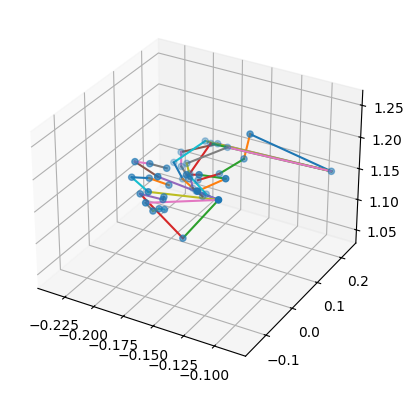

In [24]:
# Visualize the BMC-optimized hands
pose2video(
    poses_3d_body,
    output_3d_dir,
    'visualization_bmc_hands',
    optimized_hand_poses_3d,
    render_body=False,
    dynamic_limits=True
)

## Method 2: Weighted Triangulation for Hand Poses

This approach reconstructs 3D hand poses using weighted triangulation, similar to how body keypoints are reconstructed. It uses the keypoint confidence scores as weights for the triangulation process.

1. Prepare hand keypoints from all cameras
2. Match detected hands to the skeletal model's wrists
3. Apply weighted triangulation using confidence scores
4. Apply temporal smoothing

In [55]:
def triangulate_hand_keypoints(hand_poses_2d, camera_intrinsics, camera_extrinsics, camera_matrices, distortion_coeffs, frame_idx=0, hand_id_mapping=None):
    """
    Triangulate 3D hand keypoints from 2D observations across multiple cameras using weighted triangulation.
    
    Args:
        hand_poses_2d: Dictionary of 2D hand poses for each camera
        camera_intrinsics: Camera intrinsic matrices
        camera_extrinsics: Camera extrinsic parameters
        camera_matrices: Camera projection matrices
        distortion_coeffs: Camera distortion coefficients
        frame_idx: Current frame index
        hand_id_mapping: Optional dictionary mapping camera name to {obj_id: hand_side}, where hand_side is 0 for left and 1 for right
        
    Returns:
        Triangulated 3D hand keypoints
    """
    # Match hands to left/right wrists based on initial hand poses
    left_hand_2d = {}  # camera_name -> 2D keypoints for left hand
    right_hand_2d = {}  # camera_name -> 2D keypoints for right hand
    
    if hand_id_mapping is None:
        # Use matching to determine left/right hands
        
        # First create initial oriented hands to match 2D detections to left/right hand
        oriented_hands = np.concatenate([
            orient_canonical_hand(CANONICAL_HAND_POSE_3D, poses_3d_body[frame_idx], side='left'),
            orient_canonical_hand(CANONICAL_HAND_POSE_3D, poses_3d_body[frame_idx], side='right')
        ])
        
        # Match detected hands to left/right hands
        for cam_name, hand_pose_2d in hand_poses_2d.items():
            if frame_idx >= len(hand_pose_2d) or not hand_pose_2d[frame_idx]:
                continue
                
            (best_match1, min_error1), (best_match2, min_error2) = match_hand_poses(
                oriented_hands, hand_pose_2d[frame_idx], 
                camera_intrinsics[cam_name].reshape(3, 3),
                camera_extrinsics[cam_name][0], camera_extrinsics[cam_name][1],
                distortion_coeffs[cam_name], just_wrist=False
            )
            
            if best_match1 is not None:
                left_hand_2d[cam_name] = {
                    'keypoints': hand_pose_2d[frame_idx][best_match1].keypoints.squeeze(),
                    'scores': hand_pose_2d[frame_idx][best_match1].keypoint_scores.squeeze()
                }
                
            if best_match2 is not None:
                right_hand_2d[cam_name] = {
                    'keypoints': hand_pose_2d[frame_idx][best_match2].keypoints.squeeze(),
                    'scores': hand_pose_2d[frame_idx][best_match2].keypoint_scores.squeeze()
                }
    else:
        # Use provided mapping to assign hands directly
        for cam_name, hand_pose_2d in hand_poses_2d.items():
            if frame_idx >= len(hand_pose_2d) or not hand_pose_2d[frame_idx]:
                continue
                
            # Get the mapping for this camera
            cam_mapping = hand_id_mapping.get(cam_name, {})
            
            # Process each detected hand
            for obj_id, hand_data in hand_pose_2d[frame_idx].items():
                # Check if we have a valid hand detection
                
                # Check if this object ID is in the mapping
                if obj_id in cam_mapping:
                    # 0 = left hand, 1 = right hand
                    if cam_mapping[obj_id] == 0:
                        left_hand_2d[cam_name] = {
                            'keypoints': hand_data.keypoints.squeeze(),
                            'scores': hand_data.keypoint_scores.squeeze()
                        }
                    elif cam_mapping[obj_id] == 1:
                        right_hand_2d[cam_name] = {
                            'keypoints': hand_data.keypoints.squeeze(),
                            'scores': hand_data.keypoint_scores.squeeze()
                        }
    
    # Get oriented hands for fallback case
    oriented_hands = np.concatenate([
        orient_canonical_hand(CANONICAL_HAND_POSE_3D, poses_3d_body[frame_idx], side='left'),
        orient_canonical_hand(CANONICAL_HAND_POSE_3D, poses_3d_body[frame_idx], side='right')
    ])
    
    # Triangulate each keypoint for left and right hand
    left_hand_3d = np.zeros((num_keypoints_hands, 3))
    right_hand_3d = np.zeros((num_keypoints_hands, 3))
    
    # If we don't have enough cameras with hand detections, use initial oriented hands
    if len(left_hand_2d) < 2:
        left_hand_3d = oriented_hands[:num_keypoints_hands]
    if len(right_hand_2d) < 2:
        right_hand_3d = oriented_hands[num_keypoints_hands:]
    
    # Triangulate each keypoint independently
    for kp_idx in range(num_keypoints_hands):
        # Process left hand keypoints
        if len(left_hand_2d) >= 2:  # Need at least 2 cameras for triangulation
            points_2d = []
            cam_matrices = []
            weights = []
            
            for cam_name, hand_data in left_hand_2d.items():
                # Only use keypoints with sufficient confidence
                if hand_data['scores'][kp_idx] > 0.3:
                    kp = hand_data['keypoints'][kp_idx]
                    
                    # Undistort the point
                    K = camera_intrinsics[cam_name].reshape(3, 3)
                    dist = distortion_coeffs[cam_name]
                    kp_undistorted = cv2.undistortPoints(np.array([[kp]]), K, dist, None, K).reshape(2)
                    
                    points_2d.append(kp_undistorted)
                    cam_matrices.append(camera_matrices[cam_name])
                    weights.append(hand_data['scores'][kp_idx])
            
            if len(points_2d) >= 2:
                # Perform weighted triangulation
                points_2d = np.array(points_2d)
                cam_matrices = np.array(cam_matrices)
                weights = np.array(weights)
                
                # Normalize weights
                weights = weights / np.sum(weights)
                
                # Create weighted system of equations A*X = 0
                A = np.zeros((2 * len(points_2d), 4))
                for i, (point, P, w) in enumerate(zip(points_2d, cam_matrices, weights)):
                    x, y = point
                    A[2*i] = w * (x * P[2] - P[0])
                    A[2*i+1] = w * (y * P[2] - P[1])
                
                # Solve using SVD
                _, _, V = np.linalg.svd(A)
                point_3d_h = V[-1]
                point_3d = point_3d_h[:3] / point_3d_h[3]
                left_hand_3d[kp_idx] = point_3d
        
        # Process right hand keypoints (similar approach)
        if len(right_hand_2d) >= 2:
            points_2d = []
            cam_matrices = []
            weights = []
            
            for cam_name, hand_data in right_hand_2d.items():
                if hand_data['scores'][kp_idx] > 0.3:
                    kp = hand_data['keypoints'][kp_idx]
                    
                    # Undistort the point
                    K = camera_intrinsics[cam_name].reshape(3, 3)
                    dist = distortion_coeffs[cam_name]
                    kp_undistorted = cv2.undistortPoints(np.array([[kp]]), K, dist, None, K).reshape(2)
                    
                    points_2d.append(kp_undistorted)
                    cam_matrices.append(camera_matrices[cam_name])
                    weights.append(hand_data['scores'][kp_idx])
            
            if len(points_2d) >= 2:
                # Perform weighted triangulation
                points_2d = np.array(points_2d)
                cam_matrices = np.array(cam_matrices)
                weights = np.array(weights)
                
                # Normalize weights
                weights = weights / np.sum(weights)
                
                # Create weighted system of equations A*X = 0
                A = np.zeros((2 * len(points_2d), 4))
                for i, (point, P, w) in enumerate(zip(points_2d, cam_matrices, weights)):
                    x, y = point
                    A[2*i] = w * (x * P[2] - P[0])
                    A[2*i+1] = w * (y * P[2] - P[1])
                
                # Solve using SVD
                _, _, V = np.linalg.svd(A)
                point_3d_h = V[-1]
                point_3d = point_3d_h[:3] / point_3d_h[3]
                right_hand_3d[kp_idx] = point_3d
    
    # Enforce wrist positions from body model if they exist
    # Left wrist (index 9 in body model, index 0 in hand model)
    if np.linalg.norm(poses_3d_body[frame_idx][9]) > 0:
        # Shift the entire hand to match body wrist position
        offset = poses_3d_body[frame_idx][9] - left_hand_3d[0]
        left_hand_3d += offset
    
    # Right wrist (index 10 in body model, index 0 in hand model)
    if np.linalg.norm(poses_3d_body[frame_idx][10]) > 0:
        # Shift the entire hand to match body wrist position
        offset = poses_3d_body[frame_idx][10] - right_hand_3d[0]
        right_hand_3d += offset
    
    # Combine left and right hand
    hand_3d = np.concatenate([left_hand_3d, right_hand_3d])
    return hand_3d

Hand poses already found, skipping


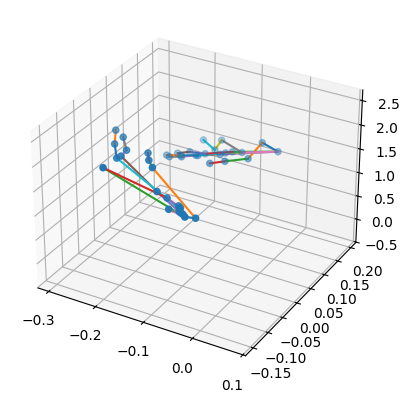

In [26]:
# Method 2: Weighted Triangulation for Hand Poses
if not FORCE_RETRAIN and os.path.exists(os.path.join(output_3d_dir, 'hand_poses_3d_triangulation.npz')):
    print("Hand poses already found, skipping")
    smoothed_triangulated_hands = np.load(os.path.join(output_3d_dir, 'hand_poses_3d_triangulation.npz'))['poses_3d']
else:
    triangulated_hand_poses_3d = []

    for frame_idx in range(len(poses_3d_body)):
        # Triangulate hand keypoints for this frame
        hand_3d = triangulate_hand_keypoints(
            hand_poses_2d,
            camera_intrinsics,
            camera_extrinsics,
            camera_matrices,
            distortion_coeffs,
            frame_idx
        )
        triangulated_hand_poses_3d.append(hand_3d)
        print(f"Triangulated hand pose for frame {frame_idx}: {hand_3d.shape}")

    triangulated_hand_poses_3d = np.array(triangulated_hand_poses_3d)
    print(f"Triangulated hands shape: {triangulated_hand_poses_3d.shape}")

    # Apply temporal smoothing to reduce jitter
    from scipy.signal import savgol_filter
    smoothed_triangulated_hands = savgol_filter(triangulated_hand_poses_3d, 
                                            window_length=15, # Must be odd and <= num_frames
                                            polyorder=3,
                                            axis=0)

    # Save results for triangulation-based approach
    output_file_triangulation = os.path.join(output_3d_dir, 'hand_poses_3d_triangulation.npz')
    np.savez(
        output_file_triangulation,
        poses_3d=smoothed_triangulated_hands,
    )

# Visualize triangulated hands
pose2video(
    poses_3d_body,
    output_3d_dir,
    'visualization_triangulated_hands',
    smoothed_triangulated_hands,
    render_body=False,
    dynamic_limits=True
)

## Method 3: Optimization without BMC Constraints

This method optimizes hand poses using only weighted reprojection error and temporal consistency, without the biomechanical constraints used in the original implementation.

1. Create a similar optimization framework to the original
2. Remove the BMC loss component
3. Adjust the optimization weights for reprojection error and temporal consistency

In [47]:
def optimize_hand_pose_no_bmc(initial_pose, filtered_hand_poses_2d, camera_intrinsics, camera_extrinsics, distortion_coeffs, previous_pose=None, lambdas=[1.0, 0.5]):
    """
    Optimize 3D hand pose without BMC constraints, using only weighted reprojection error and temporal consistency.
    Uses PyTorch operations and autograd for faster optimization.
    """
    # Convert inputs to torch tensors
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Initialize the optimization variable as a PyTorch tensor requiring gradients
    x_tensor = torch.tensor(initial_pose.flatten(), dtype=torch.float32, device=device, requires_grad=True)
    
    if previous_pose is not None:
        prev_pose_tensor = torch.tensor(previous_pose.flatten(), dtype=torch.float32, device=device)
    else:
        prev_pose_tensor = None
        
    # Setup camera parameters as tensors
    camera_params = {}
    for cam_name, hand_pose_2d in filtered_hand_poses_2d.items():
        intr = torch.tensor(camera_intrinsics[cam_name].reshape(3, 3), dtype=torch.float32, device=device)
        rotation = torch.tensor(camera_extrinsics[cam_name][0], dtype=torch.float32, device=device)
        translation = torch.tensor(camera_extrinsics[cam_name][1], dtype=torch.float32, device=device)
        distortion = torch.tensor(distortion_coeffs[cam_name], dtype=torch.float32, device=device)
        
        keypoints = torch.tensor(hand_pose_2d.keypoints.squeeze(), dtype=torch.float32, device=device)
        keypoint_scores = torch.tensor(hand_pose_2d.keypoint_scores.squeeze(), dtype=torch.float32, device=device)
        
        camera_params[cam_name] = {
            'intrinsics': intr,
            'rotation': rotation,
            'translation': translation,
            'distortion': distortion,
            'keypoints': keypoints,
            'keypoint_scores': keypoint_scores
        }
        
    # Define the project_points_torch function for differentiable projection
    def project_points_torch(points_3d, intrinsics, rotation, translation, distortion):
        """Differentiable projection of 3D points to 2D using PyTorch."""
        # Apply rotation and translation
        points_rotated = torch.matmul(points_3d, rotation.transpose(-1, -2)) + translation
        
        # Project to image plane (normalized coordinates)
        x = points_rotated[:, 0] / points_rotated[:, 2]
        y = points_rotated[:, 1] / points_rotated[:, 2]
        
        # Apply radial distortion (simplified, can be expanded)
        r2 = x*x + y*y
        radial = 1.0 + distortion[0]*r2 + distortion[1]*(r2*r2)
        
        xd = x * radial
        yd = y * radial
        
        # Apply tangential distortion (simplified)
        tangential_x = 2 * distortion[2] * x * y + distortion[3] * (r2 + 2 * x * x)
        tangential_y = distortion[2] * (r2 + 2 * y * y) + 2 * distortion[3] * x * y
        
        xd = xd + tangential_x
        yd = yd + tangential_y
        
        # Apply camera matrix
        u = intrinsics[0, 0] * xd + intrinsics[0, 2]
        v = intrinsics[1, 1] * yd + intrinsics[1, 2]
        
        return torch.stack([u, v], dim=-1)
    
    # Define the loss function with PyTorch operations
    def loss_fn(x_param):
        x_reshaped = x_param.reshape(-1, 3)
        
        # Reprojection loss
        repr_loss = 0.0
        total_score = 0.0
        
        for cam_name, params in camera_params.items():
            # Project 3D points to 2D using our PyTorch-based function
            projected_points = project_points_torch(
                x_reshaped, 
                params['intrinsics'], 
                params['rotation'], 
                params['translation'], 
                params['distortion']
            )
            
            # Calculate reprojection error with valid keypoints
            valid_mask = params['keypoint_scores'] > 0.1
            
            if torch.any(valid_mask):
                # Calculate distance between projected and observed keypoints
                error = torch.norm(
                    projected_points[valid_mask] - params['keypoints'][valid_mask],
                    dim=1
                )
                
                # Weight error by keypoint scores
                weighted_error = error * params['keypoint_scores'][valid_mask]
                repr_loss += torch.sum(weighted_error)
                total_score += torch.sum(params['keypoint_scores'][valid_mask])
        
        # Avoid division by zero
        if total_score > 0:
            repr_loss = repr_loss / total_score
        
        # Temporal consistency loss
        temp_loss = 0.0
        if prev_pose_tensor is not None:
            temp_loss = torch.norm(x_param - prev_pose_tensor)
        
        # Combine all losses with weights
        total_loss = lambdas[0] * repr_loss + lambdas[1] * temp_loss
        
        return total_loss
    
    # Initialize LBFGS optimizer
    optimizer = torch.optim.LBFGS(
        [x_tensor], 
        line_search_fn='strong_wolfe',
        max_iter=20,
        tolerance_grad=1e-7,
        tolerance_change=1e-9
    )
    
    # Initial loss calculation
    initial_loss = loss_fn(x_tensor)
    print(f"Initial loss (no BMC): {initial_loss.item()}")
    
    # Define closure function for optimizer
    def closure():
        optimizer.zero_grad()
        loss = loss_fn(x_tensor)
        loss.backward()
        return loss
    
    # Run optimization
    optimizer.step(closure)
    
    # Final loss and results
    final_loss = loss_fn(x_tensor)
    print(f"Final loss (no BMC): {final_loss.item()}")
    
    # Convert result back to numpy
    optimized_hand = x_tensor.detach().cpu().numpy().reshape(-1, 3)
    
    return optimized_hand

In [58]:
def optimize_poses_no_bmc(initial_hand_poses_3d, hand_poses_2d, camera_intrinsics, camera_extrinsics, distortion_coeffs, frame_idx=0, previous_pose=None, hand_id_mapping=None):
    """
    Optimize 3D hand poses by minimizing reprojection error across multiple views without BMC constraints.
    
    Args:
        initial_hand_poses_3d: Initial 3D hand poses
        hand_poses_2d: Dictionary of 2D hand poses for each camera
        camera_intrinsics: Dictionary of camera intrinsic matrices
        camera_extrinsics: Dictionary of camera extrinsic parameters
        distortion_coeffs: Dictionary of camera distortion coefficients
        frame_idx: Current frame index
        previous_pose: Previous optimized pose for temporal consistency
        hand_id_mapping: Dictionary mapping camera names to a dict of object IDs to hand side (0=left, 1=right)
    """
    optimized_hands = []
    filtered_hand_poses_2d1 = {}  # Left hand
    filtered_hand_poses_2d2 = {}  # Right hand
    
    if previous_pose is not None:
        previous_pose1 = previous_pose[:num_keypoints_hands]  # Left hand
        previous_pose2 = previous_pose[num_keypoints_hands:]  # Right hand
    else:
        previous_pose1 = None
        previous_pose2 = None

    for cam_name, hand_pose_2d in hand_poses_2d.items():
        # Check if we have a predefined mapping for this camera
        if hand_id_mapping is not None and cam_name in hand_id_mapping:
            # Use predefined mapping instead of matching
            for obj_id, hand_side in hand_id_mapping[cam_name].items():
                if frame_idx < len(hand_pose_2d) and obj_id in hand_pose_2d[frame_idx]:
                    if hand_side == 0:  # Left hand
                        filtered_hand_poses_2d1[cam_name] = hand_pose_2d[frame_idx][obj_id]
                    elif hand_side == 1:  # Right hand
                        filtered_hand_poses_2d2[cam_name] = hand_pose_2d[frame_idx][obj_id]
        else:
            # No mapping available, perform matching
            if frame_idx < len(hand_pose_2d):
                (best_match1, min_error1), (best_match2, min_error2) = match_hand_poses(
                    initial_hand_poses_3d, hand_pose_2d[frame_idx], camera_intrinsics[cam_name],
                    camera_extrinsics[cam_name][0], camera_extrinsics[cam_name][1],
                    distortion_coeffs[cam_name], just_wrist=False
                )
                if best_match1 is not None:
                    filtered_hand_poses_2d1[cam_name] = hand_pose_2d[frame_idx][best_match1]
                if best_match2 is not None:
                    filtered_hand_poses_2d2[cam_name] = hand_pose_2d[frame_idx][best_match2]

    # Use our PyTorch-based optimization without BMC for both hands
    optimized_hand1 = optimize_hand_pose_no_bmc(
        initial_hand_poses_3d[:num_keypoints_hands], filtered_hand_poses_2d1,
        camera_intrinsics, camera_extrinsics, distortion_coeffs, 
        previous_pose=previous_pose1
    )
    
    optimized_hand2 = optimize_hand_pose_no_bmc(
        initial_hand_poses_3d[num_keypoints_hands:], filtered_hand_poses_2d2,
        camera_intrinsics, camera_extrinsics, distortion_coeffs, 
        previous_pose=previous_pose2
    )

    # Combine optimized hands
    combined_hands = np.concatenate([optimized_hand1, optimized_hand2], axis=0)
    return combined_hands

Hand poses already found, skipping


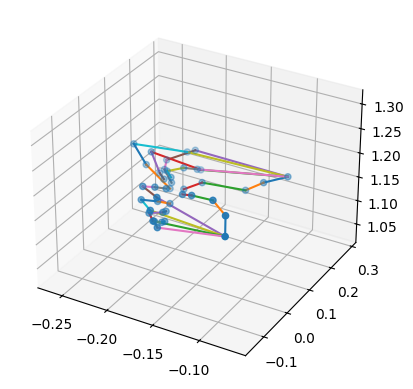

In [29]:
# Method 3: Optimization without BMC Constraints
if not FORCE_RETRAIN and os.path.exists(os.path.join(output_3d_dir, 'hand_poses_3d_no_bmc.npz')):
    print("Hand poses already found, skipping")
    nobmc_optimized_hand_poses_3d = np.load(os.path.join(output_3d_dir, 'hand_poses_3d_no_bmc.npz'))['poses_3d']
else:
    nobmc_optimized_hand_poses_3d = []

    for frame_idx in range(len(poses_3d_body)):
        if frame_idx == 0:
            # For first frame, use initial hand poses
            initial_pose = np.concatenate([
                orient_canonical_hand(CANONICAL_HAND_POSE_3D, poses_3d_body[frame_idx], side='left'),
                orient_canonical_hand(CANONICAL_HAND_POSE_3D, poses_3d_body[frame_idx], side='right')
            ])
            
            # Optimize without BMC
            optimized_hand = optimize_poses_no_bmc(
                initial_pose, hand_poses_2d,
                camera_intrinsics, camera_extrinsics, distortion_coeffs
            )
            nobmc_optimized_hand_poses_3d.append(optimized_hand)
            prev_optimized_hand = optimized_hand
        else:
            # For subsequent frames, initialize hands from previous optimized pose
            left_hand = initialize_hand_pose_for_next_frame(
                prev_optimized_hand[:num_keypoints_hands], 
                poses_3d_body[frame_idx], 
                poses_3d_body[frame_idx-1], 
                side='left'
            )
            right_hand = initialize_hand_pose_for_next_frame(
                prev_optimized_hand[num_keypoints_hands:], 
                poses_3d_body[frame_idx], 
                poses_3d_body[frame_idx-1], 
                side='right'
            )
            initial_pose = np.concatenate([left_hand, right_hand])
            
            # Optimize without BMC
            optimized_hand = optimize_poses_no_bmc(
                initial_pose, hand_poses_2d,
                camera_intrinsics, camera_extrinsics, distortion_coeffs,
                frame_idx=frame_idx, previous_pose=prev_optimized_hand
            )
            nobmc_optimized_hand_poses_3d.append(optimized_hand)
            prev_optimized_hand = optimized_hand
            
        print(f"No-BMC optimized hand pose for frame {frame_idx}: {optimized_hand.shape}")

    nobmc_optimized_hand_poses_3d = np.array(nobmc_optimized_hand_poses_3d)
    print(f"No-BMC optimized hands shape: {nobmc_optimized_hand_poses_3d.shape}")

    # Save results for No-BMC optimization
    output_file_nobmc = os.path.join(output_3d_dir, 'hand_poses_3d_no_bmc.npz')
    np.savez(
        output_file_nobmc,
        poses_3d=nobmc_optimized_hand_poses_3d,
    )

# Visualize No-BMC optimized hands
pose2video(
    poses_3d_body,
    output_3d_dir,
    'visualization_nobmc_hands',
    nobmc_optimized_hand_poses_3d,
    render_body=False,
    dynamic_limits=True
)

## Results Comparison

We've implemented three different methods for 3D hand pose reconstruction:

1. **BMC-based Optimization**: Uses biomechanical constraints along with weighted reprojection error and temporal consistency
   - Results saved in `hand_poses_3d_bmc.npz`
   - Visualization in `visualization_bmc_hands.mp4`

2. **Weighted Triangulation**: Uses simple weighted triangulation based on keypoint confidence scores
   - Results saved in `hand_poses_3d_triangulation.npz`
   - Visualization in `visualization_triangulated_hands.mp4`

3. **Optimization without BMC**: Uses optimization with only reprojection error and temporal consistency
   - Results saved in `hand_poses_3d_no_bmc.npz`
   - Visualization in `visualization_nobmc_hands.mp4`

Each method has different strengths and weaknesses:

- **BMC-based optimization** produces the most anatomically plausible poses but may over-constrain the solution
- **Weighted triangulation** is simpler and faster but may produce less stable results, especially with occlusions
- **Optimization without BMC** balances between the approaches with more freedom than BMC but still enforces temporal consistency

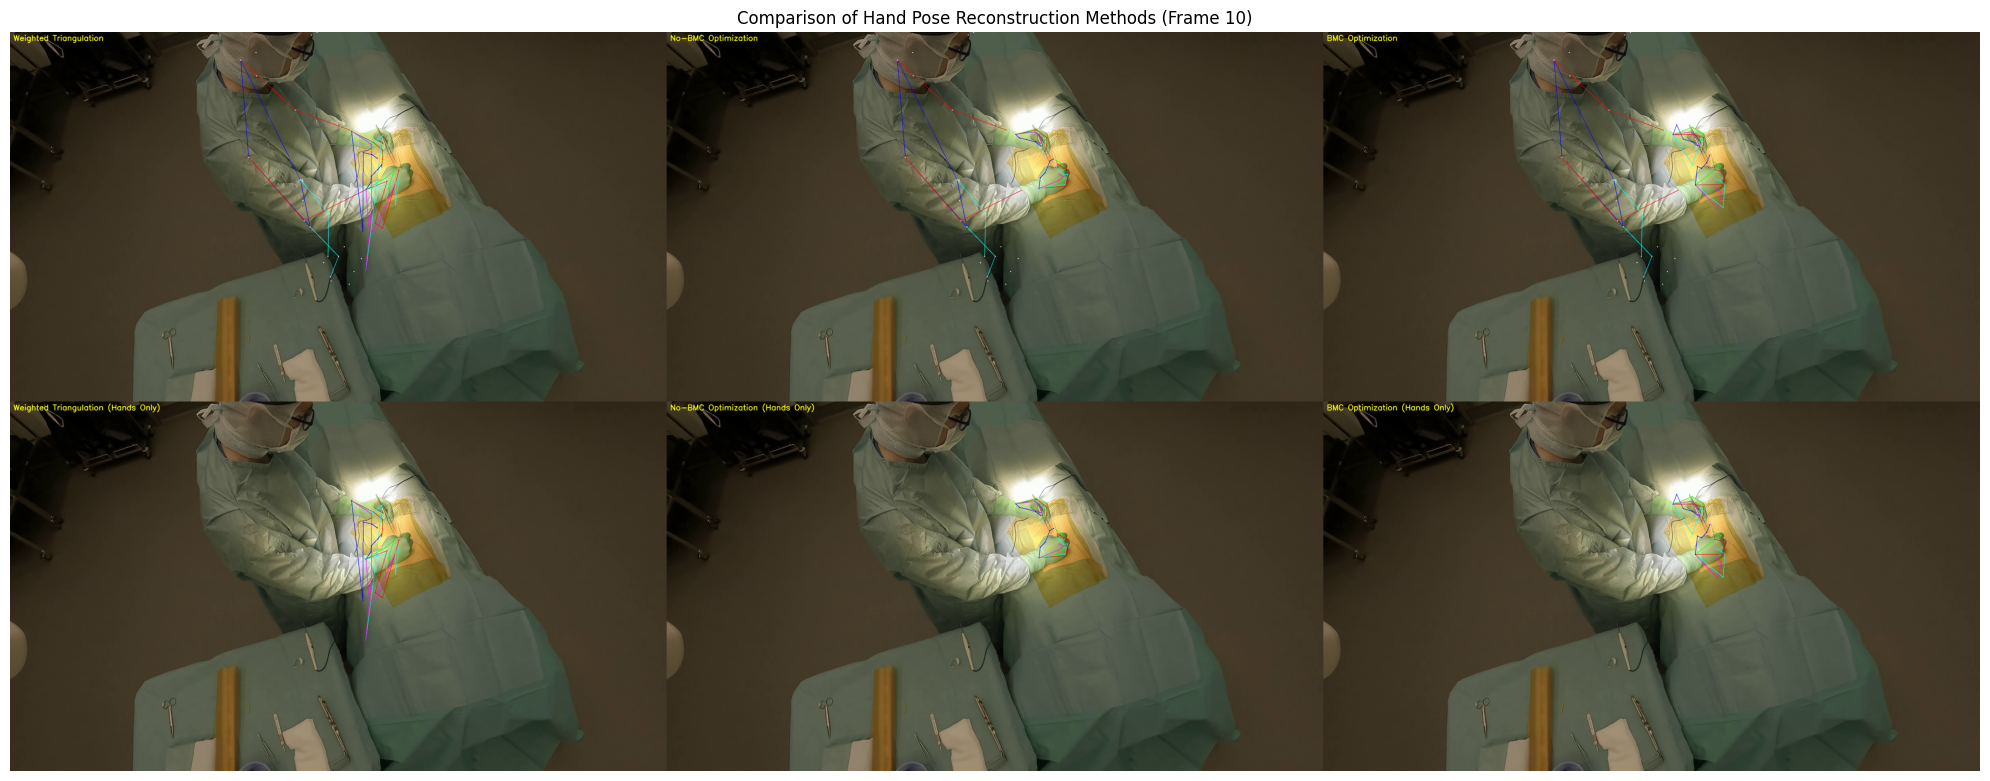

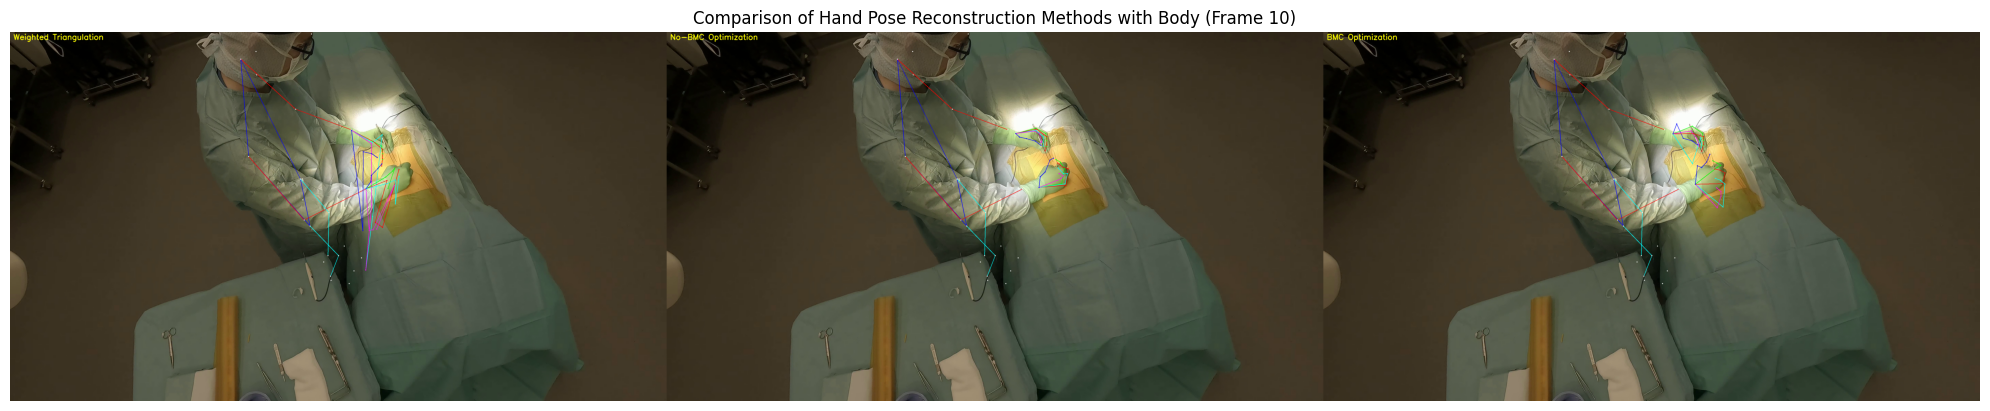

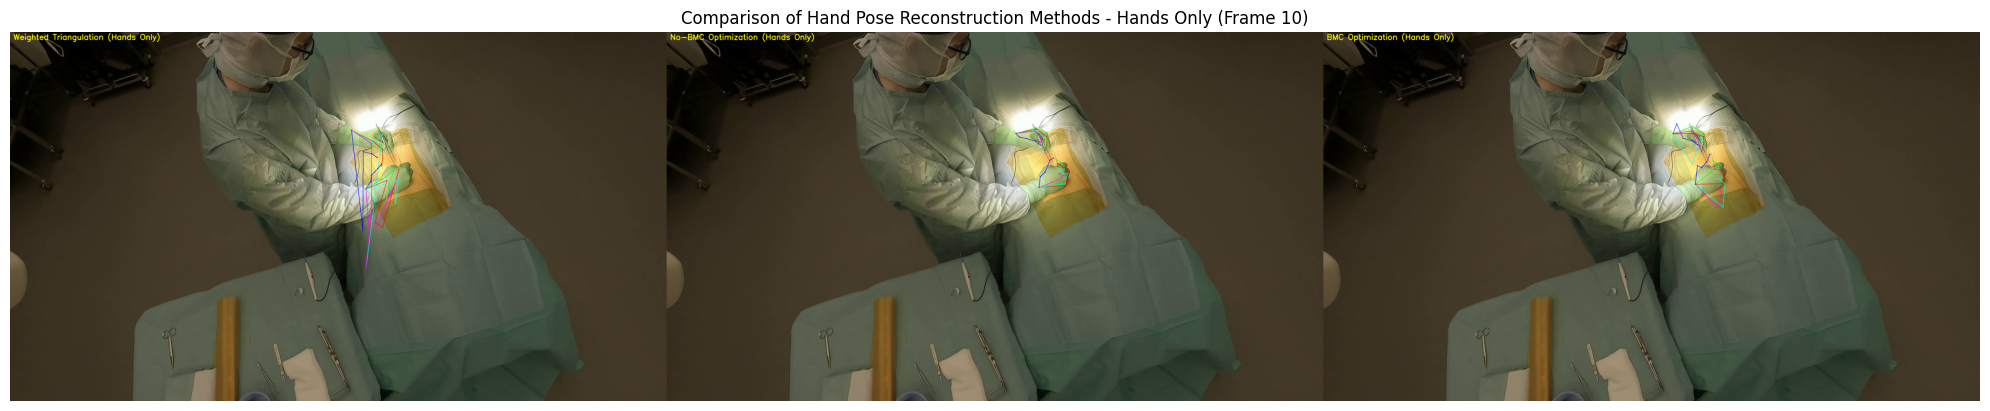

In [30]:
# Compare visualizations of the three methods on a sample frame
camera = 'gopro8'
frame_idx = 10  # Choose a frame for comparison

video_path = os.path.join(data_dir, f'{camera}_synced_cut.MP4')
cap = cv2.VideoCapture(video_path)
cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
ret, frame = cap.read()
cap.release()

if ret:
    # Get camera parameters
    cam_intrinsics = camera_intrinsics[camera].reshape(3,3)
    cam_extrinsics = camera_extrinsics[camera]
    cam_distortion = distortion_coeffs[camera]
    
    # Create visualizations for each method with body pose
    frame_bmc = visualize_poses(frame.copy(), poses_3d_body[frame_idx], optimized_hand_poses_3d[frame_idx], 
                              hand_poses_2d, cam_intrinsics, cam_extrinsics[0], cam_extrinsics[1], 
                              cam_distortion, frame_idx, camera)
    
    frame_triang = visualize_poses(frame.copy(), poses_3d_body[frame_idx], smoothed_triangulated_hands[frame_idx], 
                                 hand_poses_2d, cam_intrinsics, cam_extrinsics[0], cam_extrinsics[1], 
                                 cam_distortion, frame_idx, camera)
    
    frame_nobmc = visualize_poses(frame.copy(), poses_3d_body[frame_idx], nobmc_optimized_hand_poses_3d[frame_idx], 
                                hand_poses_2d, cam_intrinsics, cam_extrinsics[0], cam_extrinsics[1], 
                                cam_distortion, frame_idx, camera)
    
    # Create visualizations for each method with only hands (no body)
    frame_bmc_hands = visualize_poses(frame.copy(), None, optimized_hand_poses_3d[frame_idx], 
                                    hand_poses_2d, cam_intrinsics, cam_extrinsics[0], cam_extrinsics[1], 
                                    cam_distortion, frame_idx, camera, draw_body=False)
    
    frame_triang_hands = visualize_poses(frame.copy(), None, smoothed_triangulated_hands[frame_idx], 
                                       hand_poses_2d, cam_intrinsics, cam_extrinsics[0], cam_extrinsics[1], 
                                       cam_distortion, frame_idx, camera, draw_body=False)
    
    frame_nobmc_hands = visualize_poses(frame.copy(), None, nobmc_optimized_hand_poses_3d[frame_idx], 
                                      hand_poses_2d, cam_intrinsics, cam_extrinsics[0], cam_extrinsics[1], 
                                      cam_distortion, frame_idx, camera, draw_body=False)
    
    # Add clear method labels to the frames
    label_params = {
        'fontFace': cv2.FONT_HERSHEY_SIMPLEX,
        'org': (20, 50),
        'fontScale': 1.5,
        'color': (0, 255, 255),  # Yellow
        'thickness': 3,
    }
    
    cv2.putText(frame_bmc, "BMC Optimization", **label_params)
    cv2.putText(frame_triang, "Weighted Triangulation", **label_params)
    cv2.putText(frame_nobmc, "No-BMC Optimization", **label_params)
    
    cv2.putText(frame_bmc_hands, "BMC Optimization (Hands Only)", **label_params)
    cv2.putText(frame_triang_hands, "Weighted Triangulation (Hands Only)", **label_params)
    cv2.putText(frame_nobmc_hands, "No-BMC Optimization (Hands Only)", **label_params)
    
    # Display comparison - full pose (body + hands)
    comparison_full = np.hstack([frame_triang, frame_nobmc, frame_bmc])
    
    # Display comparison - hands only
    comparison_hands = np.hstack([frame_triang_hands, frame_nobmc_hands, frame_bmc_hands])
    
    # Stack both comparisons vertically
    comparison = np.vstack([comparison_full, comparison_hands])
    
    # Resize for better display if needed
    comparison = cv2.resize(comparison, (0, 0), fx=0.7, fy=0.7)
    
    plt.figure(figsize=(20, 15))
    plt.imshow(cv2.cvtColor(comparison, cv2.COLOR_BGR2RGB))
    plt.title(f"Comparison of Hand Pose Reconstruction Methods (Frame {frame_idx})")
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(os.path.join(output_3d_dir, f'{camera}_{frame_idx}_hand_methods_comparison.png'), dpi=300, bbox_inches='tight')
    plt.show()
    
    # Save individual comparisons too
    plt.figure(figsize=(20, 7))
    plt.imshow(cv2.cvtColor(comparison_full, cv2.COLOR_BGR2RGB))
    plt.title(f"Comparison of Hand Pose Reconstruction Methods with Body (Frame {frame_idx})")
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(os.path.join(output_3d_dir, f'{camera}_{frame_idx}_hand_methods_with_body.png'), dpi=300, bbox_inches='tight')
    
    plt.figure(figsize=(20, 7))
    plt.imshow(cv2.cvtColor(comparison_hands, cv2.COLOR_BGR2RGB))
    plt.title(f"Comparison of Hand Pose Reconstruction Methods - Hands Only (Frame {frame_idx})")
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(os.path.join(output_3d_dir, f'{camera}_{frame_idx}_hand_methods_only_hands.png'), dpi=300, bbox_inches='tight')

In [31]:
def create_reprojection_videos(poses_3d_body, hand_poses_3d_dict, camera_intrinsics, 
                     camera_extrinsics, distortion_coeffs, data_dir, output_dir, 
                     camera_angles=['gopro10', 'gopro5']):
    """
    Create videos with 3D hand poses reprojected into 2D camera views from specified angles.
    
    Args:
        poses_3d_body: Array of 3D body poses for each frame
        hand_poses_3d_dict: Dictionary mapping method names to arrays of 3D hand poses
        camera_intrinsics: Dictionary of camera intrinsic matrices
        camera_extrinsics: Dictionary of camera extrinsic parameters
        distortion_coeffs: Dictionary of camera distortion coefficients
        data_dir: Directory containing input videos
        output_dir: Directory to save output videos
        camera_angles: List of camera names to use for video creation
    """
    # Check if specified camera angles exist
    available_cameras = []
    for camera in camera_angles:
        video_path = os.path.join(data_dir, f"{camera}_synced_cut.MP4")
        if os.path.exists(video_path):
            available_cameras.append(camera)
        else:
            print(f"Warning: Video for camera {camera} not found at {video_path}")
    
    if not available_cameras:
        print("No available cameras found for reprojection videos")
        return
    
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)
    
    for camera in available_cameras:
        # Load video
        video_path = os.path.join(data_dir, f"{camera}_synced_cut.MP4")
        cap = cv2.VideoCapture(video_path)
        
        # Get video properties
        frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        fps = cap.get(cv2.CAP_PROP_FPS)
        total_frames = min(len(poses_3d_body), int(cap.get(cv2.CAP_PROP_FRAME_COUNT)))
        
        # Get camera parameters
        cam_intrinsics = camera_intrinsics[camera].reshape(3, 3)
        cam_extrinsics = camera_extrinsics[camera]
        cam_rotation = cam_extrinsics[0]
        cam_translation = cam_extrinsics[1]
        cam_distortion = distortion_coeffs[camera]
        

        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        # Create video writer for each method
        video_writers = {}
        for method_name in hand_poses_3d_dict.keys():
            output_path = os.path.join(output_dir, f'{camera}_reprojection_{method_name}.mp4')
            video_writers[method_name] = cv2.VideoWriter(
                output_path, fourcc, fps, (frame_width, frame_height)
            )
        
        # Create a combined video with all methods side by side
        combined_output_path = os.path.join(output_dir, f'{camera}_reprojection_comparison.mp4')
        combined_writer = cv2.VideoWriter(
            combined_output_path, fourcc, fps, 
            (frame_width * len(hand_poses_3d_dict), frame_height)
        )
        
        # Process each frame
        frame_idx = 0
        while frame_idx < total_frames:
            ret, frame = cap.read()
            if not ret:
                break
            
            # Create visualizations for each method
            method_frames = []
            for method_name, hand_poses_3d in hand_poses_3d_dict.items():
                if frame_idx < len(hand_poses_3d):
                    # Create a copy of the frame for this method
                    method_frame = frame.copy()
                    
                    # Add method name as text label
                    cv2.putText(method_frame, method_name, (10, 30), 
                                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 255), 2)
                    
                    # Project 3D body pose to 2D
                    if frame_idx < len(poses_3d_body):
                        body_2d = project_points(poses_3d_body[frame_idx], cam_intrinsics, 
                                              cam_rotation, cam_translation, cam_distortion)
                        
                        # Create a dummy instance with the projected points for drawing
                        body_instance = type('', (), {
                            'keypoints': np.array(body_2d).reshape(1, -1, 2),
                            'keypoint_scores': np.ones((1, len(body_2d)))
                        })
                        
                        # Draw body pose
                        draw_pose(method_frame, body_instance, pose_type='body')
                    
                    # Project 3D hand pose to 2D
                    hand_3d = hand_poses_3d[frame_idx]
                    
                    # Left hand (first 21 points)
                    left_hand_2d = project_points(hand_3d[:21], cam_intrinsics,
                                                cam_rotation, cam_translation, cam_distortion)
                    
                    # Create dummy instance with projected points
                    left_hand_instance = type('', (), {
                        'keypoints': np.array(left_hand_2d).reshape(1, -1, 2),
                        'keypoint_scores': np.ones((1, len(left_hand_2d)))
                    })
                    
                    # Draw left hand pose
                    draw_pose(method_frame, left_hand_instance, pose_type='hand')
                    
                    # Right hand (last 21 points)
                    right_hand_2d = project_points(hand_3d[21:], cam_intrinsics,
                                                 cam_rotation, cam_translation, cam_distortion)
                    
                    # Create dummy instance with projected points
                    right_hand_instance = type('', (), {
                        'keypoints': np.array(right_hand_2d).reshape(1, -1, 2),
                        'keypoint_scores': np.ones((1, len(right_hand_2d)))
                    })
                    
                    # Draw right hand pose
                    draw_pose(method_frame, right_hand_instance, pose_type='hand')
                    
                    # Write frame to method-specific video
                    video_writers[method_name].write(method_frame)
                    
                    # Add to list for combined video
                    method_frames.append(method_frame)
            
            # Create combined frame with all methods side by side
            if method_frames:
                combined_frame = np.hstack(method_frames)
                combined_writer.write(combined_frame)
            
            # Increment frame index
            frame_idx += 1
            print(f"\rProcessing frame {frame_idx}/{total_frames} for camera {camera}", end='')
        
        print(f"\nFinished processing {camera} video")
        
        # Release resources
        cap.release()
        for writer in video_writers.values():
            writer.release()
        combined_writer.release()
    
    print("All reprojection videos created successfully")

In [33]:
# Create a dictionary of all hand pose methods for comparison
hand_poses_methods = {
    'BMC': optimized_hand_poses_3d,
    'Triangulation': smoothed_triangulated_hands,
    'No-BMC': nobmc_optimized_hand_poses_3d
}

# Create reprojection videos from multiple camera angles
create_reprojection_videos(
    poses_3d_body,
    hand_poses_methods,
    camera_intrinsics,
    camera_extrinsics,
    distortion_coeffs,
    data_dir,
    output_3d_dir,
    camera_angles=['gopro10', 'gopro8', 'gopro7']  # Specify which cameras to use
)

Processing frame 60/60 for camera gopro10
Finished processing gopro10 video
Processing frame 60/60 for camera gopro8
Finished processing gopro8 video
Processing frame 60/60 for camera gopro7
Finished processing gopro7 video
All reprojection videos created successfully


## Hand-ID Matching using Wholebody Pose Estimation

This section implements a function to match tracked hand object IDs with their correct hand sides (left/right) based on wholebody pose estimation. The function compares tracked hands with wholebody hands or canonical hand projections to determine consistent ID mapping across the video sequence.

In [43]:
def identify_hand_ids(hand_poses_2d, video_paths, camera_intrinsics, camera_extrinsics, distortion_coeffs, poses_3d_body, matching_threshold=50, num_frames=None, visualize=False):
    """
    Determine which object ID corresponds to which hand (left/right) by comparing tracked hands
    with wholebody pose estimation or canonical hand projections.
    
    Args:
        hand_poses_2d: Dictionary mapping camera names to 2D hand detections per frame
        video_paths: Dictionary mapping camera names to video file paths
        camera_intrinsics: Dictionary of camera intrinsic matrices
        camera_extrinsics: Dictionary of camera extrinsic parameters
        distortion_coeffs: Dictionary of camera distortion coefficients
        poses_3d_body: 3D body poses for each frame
        num_frames: Maximum number of frames to process (optional)
        visualize: Whether to visualize the matching (optional)
    
    Returns:
        Dictionary mapping camera names to dictionaries mapping object IDs to hand sides (0=left, 1=right)
    """    
    # Initialize variables to store voting results per camera
    results = {}  # {cam_name: {obj_id: hand_side}}
    
    # Determine the number of frames to process
    if num_frames is None:
        # Find the maximum number of frames in hand poses
        max_frames = 0
        for cam_name, cam_poses in hand_poses_2d.items():
            max_frames = max(max_frames, len(cam_poses))
        num_frames = max_frames
    
    print(f"Processing {num_frames} frames for hand ID matching...")
    
    # Process each camera
    for cam_name, cam_poses in hand_poses_2d.items():
        # Initialize votes for this camera
        hand_id_votes = {}  # {obj_id: {0: left_votes, 1: right_votes}}
        
        if cam_name not in video_paths:
            print(f"Warning: No video path found for camera {cam_name}")
            continue
            
        video_path = video_paths[cam_name]
        if not os.path.exists(video_path):
            print(f"Warning: Video file not found: {video_path}")
            continue
        
        # Get camera parameters
        cam_intrinsics = camera_intrinsics[cam_name].reshape(3, 3)
        cam_rotation = camera_extrinsics[cam_name][0]
        cam_translation = camera_extrinsics[cam_name][1]
        cam_distortion = distortion_coeffs[cam_name]
        
        # Open video
        cap = cv2.VideoCapture(video_path)

        bboxes_body = detect_body(video_path)
        
        # Process frames
        for frame_idx in range(min(num_frames, len(cam_poses))):
            # Skip frames with no hand detections
            if not cam_poses[frame_idx]:
                continue
                
            # Read frame
            cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
            ret, frame = cap.read()
            if not ret:
                print(f"Warning: Could not read frame {frame_idx} from {video_path}")
                continue
                
            # Estimate wholebody pose
            bbox = bboxes_body[frame_idx]
            if len(bbox) == 0:
                continue
                
            body_instances, left_hand_instances, right_hand_instances = estimate_pose(frame, bbox, pose_type='wholebody', show=False)
            if body_instances is None:
                continue
                
            # Extract body keypoints
            body_keypoints = body_instances.keypoints  # First 17 keypoints are body keypoints
            body_scores = body_instances.keypoint_scores
            
            # Extract left and right hand keypoints from wholebody pose
            left_hand_keypoints = left_hand_instances.keypoints.squeeze()
            left_hand_scores = left_hand_instances.keypoint_scores.squeeze()
            
            right_hand_keypoints = right_hand_instances.keypoints.squeeze()
            right_hand_scores = right_hand_instances.keypoint_scores.squeeze()
            
            # Check if we have valid hand detections in wholebody
            has_left_hand = left_hand_keypoints is not None and np.mean(left_hand_scores) > 0.3
            has_right_hand = right_hand_keypoints is not None and np.mean(right_hand_scores) > 0.3

            if left_hand_scores.shape[0] != 21:
                if left_hand_scores.shape[1] == 21:
                    left_hand_scores = left_hand_scores[0]
                else:
                    has_left_hand = False
            if right_hand_scores.shape[0] != 21:
                if right_hand_scores.shape[1] == 21:
                    right_hand_scores = right_hand_scores[0]
                else:
                    has_right_hand = False
            if has_left_hand:
                if left_hand_keypoints.shape[0] != 21:
                    if left_hand_keypoints.shape[1] == 21:
                        left_hand_keypoints = left_hand_keypoints[0]
                    else:
                        has_left_hand = False

            if has_right_hand:
                if right_hand_keypoints.shape[0] != 21:
                    if right_hand_keypoints.shape[1] == 21:
                        right_hand_keypoints = right_hand_keypoints[0]
                    else:
                        has_right_hand = False
            
            # If we don't have valid hand detections, use canonical hands
            if not has_left_hand:
                # Project canonical hands
                if frame_idx < len(poses_3d_body):
                    # Create canonical hands based on 3D body pose
                    if not has_left_hand:
                        left_canonical = orient_canonical_hand(CANONICAL_HAND_POSE_3D, poses_3d_body[frame_idx], side='left')
                        left_hand_keypoints = project_points(left_canonical, cam_intrinsics, cam_rotation, cam_translation, cam_distortion).squeeze()
                        has_left_hand = True
                    print("Using canonical left hand")
            if not has_right_hand:
                # Project canonical hands
                if frame_idx < len(poses_3d_body):
                    # Create canonical hands based on 3D body pose
                    if not has_right_hand:
                        right_canonical = orient_canonical_hand(CANONICAL_HAND_POSE_3D, poses_3d_body[frame_idx], side='right')
                        right_hand_keypoints = project_points(right_canonical, cam_intrinsics, cam_rotation, cam_translation, cam_distortion).squeeze()
                        has_right_hand = True
                    print("Using canonical right hand")
            
            # Compare tracked hands with wholebody hands
            for obj_id, tracked_hand in cam_poses[frame_idx].items():
                if tracked_hand is None:
                    continue
                    
                tracked_keypoints = tracked_hand.keypoints.squeeze()
                tracked_scores = tracked_hand.keypoint_scores.squeeze()
                
                # Check if this is a valid hand (sufficient keypoints with good confidence)
                if np.mean(tracked_scores) < 0.2:
                    continue
                    
                # Initialize votes for this object ID if not already done
                if obj_id not in hand_id_votes:
                    hand_id_votes[obj_id] = {0: 0, 1: 0}  # {0: left_votes, 1: right_votes}
                
                # Calculate distance to left and right hand
                left_distance = np.inf
                right_distance = np.inf
                
                if has_left_hand:
                    # Calculate distance to left hand
                    valid_mask = tracked_scores > 0.3
                    if np.any(valid_mask):
                        distances = np.linalg.norm(
                            tracked_keypoints[valid_mask, :] - left_hand_keypoints[valid_mask, :],
                            axis=1
                        )
                        left_distance = np.mean(distances)
                
                if has_right_hand:
                    # Calculate distance to right hand
                    valid_mask = tracked_scores > 0.3
                    if np.any(valid_mask):
                        distances = np.linalg.norm(
                            tracked_keypoints[valid_mask, :] - right_hand_keypoints[valid_mask, :],
                            axis=1
                        )
                        right_distance = np.mean(distances)
                
                # Vote for the closest hand
                if left_distance < right_distance:
                    if left_distance < matching_threshold:
                        hand_id_votes[obj_id][0] += 1  # Vote for left hand
                elif right_distance < matching_threshold:
                    hand_id_votes[obj_id][1] += 1  # Vote for right hand
                    
                # Visualize if requested
                if visualize:
                    vis_frame = frame.copy()
                    
                    # Draw tracked hand
                    draw_pose(vis_frame, tracked_hand, pose_type='hand')
                    
                    # Draw wholebody hands
                    if has_left_hand:
                        for i, (pt, score) in enumerate(zip(left_hand_keypoints, left_hand_scores if left_hand_scores is not None else np.ones(left_hand_keypoints.shape[0]))):
                            if score > 0.3 or left_hand_scores is None:
                                x, y = map(int, pt)
                                cv2.circle(vis_frame, (x, y), 5, (0, 0, 255), -1)  # Left hand in red
                                
                    if has_right_hand:
                        for i, (pt, score) in enumerate(zip(right_hand_keypoints, right_hand_scores if right_hand_scores is not None else np.ones(right_hand_keypoints.shape[0]))):
                            if score > 0.3 or right_hand_scores is None:
                                x, y = map(int, pt)
                                cv2.circle(vis_frame, (x, y), 5, (0, 255, 0), -1)  # Right hand in green
                    
                    # Add text showing the object ID and current vote counts
                    votes = hand_id_votes[obj_id]
                    cv2.putText(vis_frame, f"Camera: {cam_name}, ID: {obj_id}, Left: {votes[0]}, Right: {votes[1]}", 
                               (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)
                    
                    # Display the frame
                    cv2.namedWindow("Hand ID Matching", cv2.WINDOW_NORMAL)
                    cv2.resizeWindow("Hand ID Matching", 1280, 720)
                    cv2.imshow("Hand ID Matching", vis_frame)
                    key = cv2.waitKey(100)  # Short delay to see visualization
                    if key == 27:  # ESC to exit
                        visualize = False
                        cv2.destroyAllWindows()
        
        # Release video
        cap.release()
        
        # Determine final hand ID mapping for this camera based on voting
        camera_mapping = {}
        for obj_id, votes in hand_id_votes.items():
            if votes[0] + votes[1] < num_frames // 2:
                continue
            # Assign hand with more votes
            camera_mapping[obj_id] = 0 if votes[0] > votes[1] else 1
            print(f"Camera {cam_name}, Object ID {obj_id}: {votes[0]} votes for left hand, {votes[1]} votes for right hand -> Assigned to {'left' if camera_mapping[obj_id] == 0 else 'right'} hand")
        
        # Store results for this camera
        results[cam_name] = camera_mapping
    
    if visualize:
        cv2.destroyAllWindows()
        
    return results

In [44]:
# Prepare video paths dictionary for the identify_hand_ids function
video_paths = {}
for cam_name in hand_poses_2d.keys():
    video_paths[cam_name] = os.path.join(data_dir, f"{cam_name}_synced_cut.MP4")

# Run hand ID identification
hand_id_mapping = identify_hand_ids(
    hand_poses_2d,
    video_paths,
    camera_intrinsics,
    camera_extrinsics,
    distortion_coeffs,
    poses_3d_body,
    num_frames=30,  # Process first 30 frames (adjust as needed)
    visualize=True  # Set to True to see visual matches
)

# Update the hand tracking and optimization functions to use this mapping
print("\nHand ID mapping:")
for cam_name, mapping in hand_id_mapping.items():
    print(f"Camera {cam_name}:")
    for obj_id, hand_side in mapping.items():
        print(f"  Object ID {obj_id} -> {'Left' if hand_side == 0 else 'Right'} hand")

Processing 30 frames for hand ID matching...
inputs/cha/cha_short\gopro10_synced_cut.MP4
Camera gopro10, Object ID 0: 30 votes for left hand, 0 votes for right hand -> Assigned to left hand
inputs/cha/cha_short\gopro11_synced_cut.MP4
Camera gopro11, Object ID 0: 0 votes for left hand, 30 votes for right hand -> Assigned to right hand
Camera gopro11, Object ID 1: 30 votes for left hand, 0 votes for right hand -> Assigned to left hand
inputs/cha/cha_short\gopro5_synced_cut.MP4
Using canonical left hand
Using canonical left hand
Using canonical right hand
inputs/cha/cha_short\gopro6_synced_cut.MP4
Camera gopro6, Object ID 0: 30 votes for left hand, 0 votes for right hand -> Assigned to left hand
inputs/cha/cha_short\gopro9_synced_cut.MP4

Hand ID mapping:
Camera gopro10:
  Object ID 0 -> Left hand
Camera gopro11:
  Object ID 0 -> Right hand
  Object ID 1 -> Left hand
Camera gopro5:
Camera gopro6:
  Object ID 0 -> Left hand
Camera gopro9:


Hand poses already found with mapping, skipping
Triangulated hand poses already found with mapping, skipping
Initial loss (no BMC): 55.0194206237793
Final loss (no BMC): 5.38773250579834
Initial loss (no BMC): 103.19061279296875
Final loss (no BMC): 0.5746738314628601
No-BMC optimized hand pose with mapping for frame 0: (42, 3)
Initial loss (no BMC): 43.581024169921875
Final loss (no BMC): 4.7574920654296875
Initial loss (no BMC): 98.39945220947266
Final loss (no BMC): 0.6290115118026733
No-BMC optimized hand pose with mapping for frame 1: (42, 3)
Initial loss (no BMC): 47.923370361328125
Final loss (no BMC): 4.772657871246338
Initial loss (no BMC): 112.32475280761719
Final loss (no BMC): 1.7021710872650146
No-BMC optimized hand pose with mapping for frame 2: (42, 3)
Initial loss (no BMC): 48.403587341308594
Final loss (no BMC): 4.818079471588135
Initial loss (no BMC): 119.98208618164062
Final loss (no BMC): 2.5475621223449707
No-BMC optimized hand pose with mapping for frame 3: (42, 3

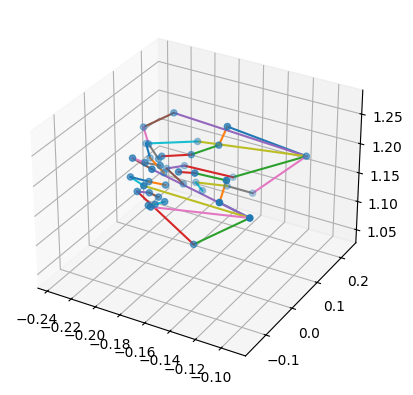

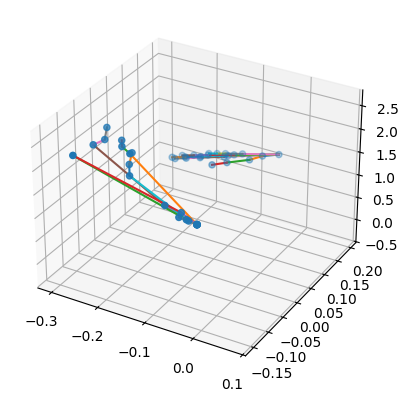

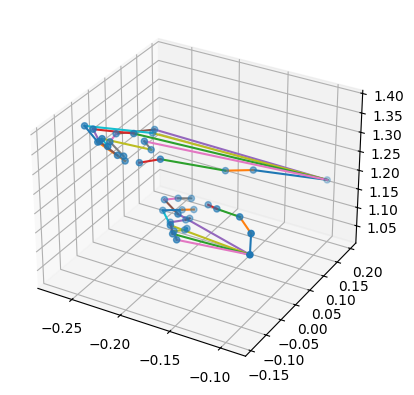

In [59]:
from scipy.signal import savgol_filter

# Use the hand_id_mapping in match_hand_poses function by adding the mapping parameter
# This will ensure hands are correctly matched during optimization process

# Example: using the hand_id_mapping in method 1 (BMC-based Optimization)
if not FORCE_RETRAIN and os.path.exists(os.path.join(output_3d_dir, 'hand_poses_3d_bmc_mapped.npz')):
    print("Hand poses already found with mapping, skipping")
    optimized_hand_poses_3d_with_mapping = np.load(os.path.join(output_3d_dir, 'hand_poses_3d_bmc_mapped.npz'))['poses_3d']
else:
    optimized_hand_poses_3d_with_mapping = []
    for frame_idx in range(len(poses_3d_body)):
        if frame_idx == 0:
            # Optimize hand poses with ID mapping
            optimized_hand = optimize_poses(
                initial_hand_poses_3d[frame_idx], hand_poses_2d,
                camera_intrinsics, camera_extrinsics, distortion_coeffs, 
                frame_idx=frame_idx, visualize=False, input_dir=data_dir,
                hand_id_mapping=hand_id_mapping  # Add the mapping here
            )
            optimized_hand_poses_3d_with_mapping.append(optimized_hand)
            prev_optimized_hand = optimized_hand
        else:
            # Optimize subsequent frames with ID mapping
            optimized_hand = optimize_poses(
                prev_optimized_hand, hand_poses_2d,
                camera_intrinsics, camera_extrinsics, distortion_coeffs, 
                frame_idx=frame_idx, previous_pose=prev_optimized_hand,
                visualize=False, input_dir=data_dir,
                hand_id_mapping=hand_id_mapping  # Add the mapping here
            )
            optimized_hand_poses_3d_with_mapping.append(optimized_hand)
            prev_optimized_hand = optimized_hand
        
        print(f"Optimized hand pose with mapping for frame {frame_idx}: {optimized_hand.shape}")

    # Convert to numpy array
    optimized_hand_poses_3d_with_mapping = np.array(optimized_hand_poses_3d_with_mapping)

    # Save results with correct mapping
    output_file_bmc_mapped = os.path.join(output_3d_dir, 'hand_poses_3d_bmc_mapped.npz')
    np.savez(
        output_file_bmc_mapped,
        poses_3d=optimized_hand_poses_3d_with_mapping,
    )

# Triangulation method with hand ID mapping
if not FORCE_RETRAIN and os.path.exists(os.path.join(output_3d_dir, 'hand_poses_3d_triangulation_mapped.npz')):
    print("Triangulated hand poses already found with mapping, skipping")
    smoothed_triangulated_hands_mapped = np.load(os.path.join(output_3d_dir, 'hand_poses_3d_triangulation_mapped.npz'))['poses_3d']

else:
    triangulated_hand_poses_3d_with_mapping = []
    for frame_idx in range(len(poses_3d_body)):
        # Triangulate hand keypoints for this frame with ID mapping
        hand_3d = triangulate_hand_keypoints(
            hand_poses_2d,
            camera_intrinsics,
            camera_extrinsics,
            camera_matrices,
            distortion_coeffs,
            frame_idx,
            hand_id_mapping=hand_id_mapping  # Use the mapping here
        )
        triangulated_hand_poses_3d_with_mapping.append(hand_3d)
        print(f"Triangulated hand pose with mapping for frame {frame_idx}: {hand_3d.shape}")

    triangulated_hand_poses_3d_with_mapping = np.array(triangulated_hand_poses_3d_with_mapping)

    # Apply temporal smoothing to reduce jitter
    smoothed_triangulated_hands_mapped = savgol_filter(triangulated_hand_poses_3d_with_mapping, 
                                            window_length=15,  # Must be odd and <= num_frames
                                            polyorder=3,
                                            axis=0)

    # Save results for triangulation with mapping
    output_file_triangulation_mapped = os.path.join(output_3d_dir, 'hand_poses_3d_triangulation_mapped.npz')
    np.savez(
        output_file_triangulation_mapped,
        poses_3d=smoothed_triangulated_hands_mapped,
    )

# Method 3: No-BMC Optimization with hand ID mapping
if not FORCE_RETRAIN and os.path.exists(os.path.join(output_3d_dir, 'hand_poses_3d_no_bmc_mapped.npz')):
    print("No-BMC optimized hand poses already found with mapping, skipping")
    nobmc_optimized_hand_poses_3d_with_mapping = np.load(os.path.join(output_3d_dir, 'hand_poses_3d_no_bmc_mapped.npz'))['poses_3d']

else:
    nobmc_optimized_hand_poses_3d_with_mapping = []

    for frame_idx in range(len(poses_3d_body)):
        if frame_idx == 0:
            # For first frame, use initial hand poses
            initial_pose = np.concatenate([
                orient_canonical_hand(CANONICAL_HAND_POSE_3D, poses_3d_body[frame_idx], side='left'),
                orient_canonical_hand(CANONICAL_HAND_POSE_3D, poses_3d_body[frame_idx], side='right')
            ])
            
            # Optimize without BMC but with hand ID mapping
            optimized_hand = optimize_poses_no_bmc(
                initial_pose, hand_poses_2d,
                camera_intrinsics, camera_extrinsics, distortion_coeffs,
                frame_idx=frame_idx, hand_id_mapping=hand_id_mapping  # Add mapping here
            )
            nobmc_optimized_hand_poses_3d_with_mapping.append(optimized_hand)
            prev_optimized_hand = optimized_hand
        else:
            # For subsequent frames, initialize hands from previous optimized pose
            left_hand = initialize_hand_pose_for_next_frame(
                prev_optimized_hand[:num_keypoints_hands], 
                poses_3d_body[frame_idx], 
                poses_3d_body[frame_idx-1], 
                side='left'
            )
            right_hand = initialize_hand_pose_for_next_frame(
                prev_optimized_hand[num_keypoints_hands:], 
                poses_3d_body[frame_idx], 
                poses_3d_body[frame_idx-1], 
                side='right'
            )
            initial_pose = np.concatenate([left_hand, right_hand])
            
            # Optimize without BMC but with hand ID mapping
            optimized_hand = optimize_poses_no_bmc(
                initial_pose, hand_poses_2d,
                camera_intrinsics, camera_extrinsics, distortion_coeffs,
                frame_idx=frame_idx, previous_pose=prev_optimized_hand,
                hand_id_mapping=hand_id_mapping  # Add mapping here
            )
            nobmc_optimized_hand_poses_3d_with_mapping.append(optimized_hand)
            prev_optimized_hand = optimized_hand
            
        print(f"No-BMC optimized hand pose with mapping for frame {frame_idx}: {optimized_hand.shape}")

    nobmc_optimized_hand_poses_3d_with_mapping = np.array(nobmc_optimized_hand_poses_3d_with_mapping)

    # Save results for No-BMC optimization with mapping
    output_file_nobmc_mapped = os.path.join(output_3d_dir, 'hand_poses_3d_no_bmc_mapped.npz')
    np.savez(
        output_file_nobmc_mapped,
        poses_3d=nobmc_optimized_hand_poses_3d_with_mapping,
    )

# Visualize all three methods with correct mapping
pose2video(
    poses_3d_body,
    output_3d_dir,
    'visualization_bmc_hands_mapped',
    optimized_hand_poses_3d_with_mapping,
    render_body=False,
    dynamic_limits=True
)

pose2video(
    poses_3d_body,
    output_3d_dir,
    'visualization_triangulated_hands_mapped',
    smoothed_triangulated_hands_mapped,
    render_body=False,
    dynamic_limits=True
)

pose2video(
    poses_3d_body,
    output_3d_dir,
    'visualization_nobmc_hands_mapped',
    nobmc_optimized_hand_poses_3d_with_mapping,
    render_body=False,
    dynamic_limits=True
)

# Create a dictionary of all hand pose methods with mapping for comparison
hand_poses_methods_mapped = {
    'BMC_Mapped': optimized_hand_poses_3d_with_mapping,
    'Triangulation_Mapped': smoothed_triangulated_hands_mapped,
    'No-BMC_Mapped': nobmc_optimized_hand_poses_3d_with_mapping
}

# Create reprojection videos comparing the mapped methods
create_reprojection_videos(
    poses_3d_body,
    hand_poses_methods_mapped,
    camera_intrinsics,
    camera_extrinsics,
    distortion_coeffs,
    data_dir,
    os.path.join(output_3d_dir, 'mapped_comparisons'),
    camera_angles=['gopro10', 'gopro8', 'gopro7']  # Specify which cameras to use
)